In [ ]:
from darksirenpop.utilities.default_globals import *
from darksirenpop.utilities.priors import *
from darksirenpop.utilities.utils import *
from darksirenpop.utilities.redshift_utils import *
from gw_selection_effects import *

import numpy as np
import pandas as pd
import healpy as hp
import torch
from tqdm import tqdm
import glob
import h5py
import json

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from astropy.cosmology import LambdaCDM
from astropy.table import Table
from astropy.coordinates import SkyCoord

from scipy.interpolate import interp1d
from scipy.integrate import simpson, romb
from scipy.special import erf, gammaincc
from scipy.stats import binom

import ligo.skymap.plot
from ligo.skymap.io.fits import read_sky_map
from ligo.skymap.postprocess import find_greedy_credible_levels
from popsummary.popresult import PopulationResult
import bilby

make_nice_plots()

# xx = np.linspace(0, 1, 100)
# plt.figure()
# plt.plot(xx, 6 * xx, color='indigo', linewidth=3)
# plt.plot(xx, 5 * xx, color='navy', linewidth=3)
# plt.plot(xx, 4 * xx, color='teal', linewidth=3)
# plt.plot(xx, 3 * xx, color='goldenrod', linewidth=3)
# plt.plot(xx, 2 * xx, color='orangered', linewidth=3)
# plt.plot(xx, 1 * xx, color='crimson', linewidth=3)
# plt.show()



opening existing popsummary file: /home/lucas/Documents/PhD/popsummary_files/gwtc5_updated_madau_dickinson_mmax_mass_TwoPeakBrokenPowerLawSmoothedMassDistribution_redshift_MadauDickinsonRedshift_magnitude_iid_spin_magnitude_gaussian_tilt_iid_spin_orientation_popsummary_result.h5


/home/lucas/Documents/PhD/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/lucas/Documents/PhD/.venv/lib/python3.13/site-packages/igwn_ligolw/lsctables.py:57: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
def get_run(key):
    date = key.split('_')[0][2:]
    y, m, d = int(date[:2]), int(date[2:4]), int(date[4:])
    
    if y < 16:
        run = 'O1'
    elif y < 18:
        run = 'O2'
    elif y < 22:
        run = 'O3'
    else:
        run = 'O4'
    return run


def run2colorsize(run):
    if run == 'O1':
        color = 'blue'
        s = 50
    elif run == 'O2':
        color = 'red'
        s = 25
    elif run == 'O3':
        color = 'green'
        s = 5
    elif run == 'O4':
        color='black'
        s = 1
    return color, s


def ecdf(a):
    x, counts = np.unique(a, return_counts=True)
    cusum = np.cumsum(counts)
    return x, cusum / cusum[-1]


def get_cdfs(posteriors):
    posteriors -= np.max(posteriors, axis=0)
    pdf = np.exp(posteriors)
    cdfs = np.cumsum(pdf, axis=0)
    cdfs /= np.max(cdfs, axis=0)
    return cdfs


def get_pdfs(posteriors, axis):
    posteriors -= np.max(posteriors, axis=0)
    pdf = np.exp(posteriors)
    norms = simpson(y=pdf, x=axis, axis=0)  # Simpson should be fine...
    pdfs = pdf / norms
    return pdfs


def load_posteriors(path):
    posteriors = np.load(path)
    shape = posteriors.shape
    return posteriors, shape


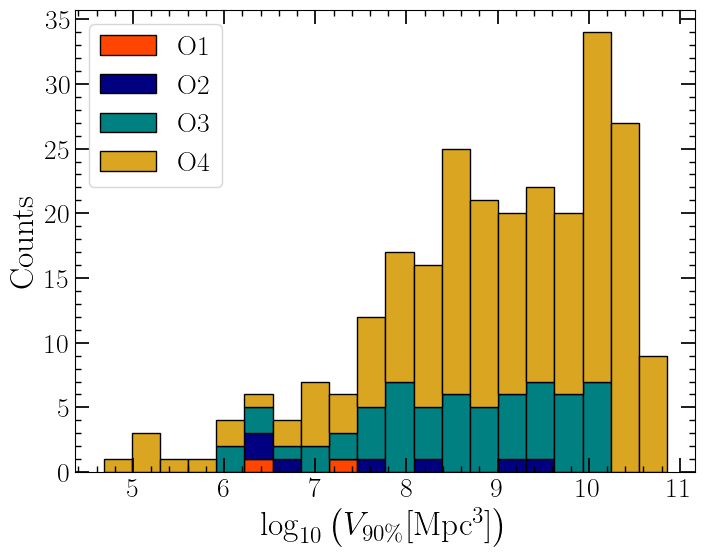

1146310458.9, -1143699382.7, +28846336524.4
9.1, -2.6, +1.4


In [3]:
v90_O1 = []
v90_O2 = []
v90_O3 = []
v90_O4 = []
all_v90 = []

# v90_O4b = []
# v90_except_O4b = []
for i, file in enumerate( sorted( glob.glob('/home/lucas/Documents/PhD/gw_data/reweighted-gwtc5/skymap_stats/*.dat') ) ):
    run = get_run(file.split('/')[-1].split('.')[0])

    stat = pd.read_csv(file, skiprows=1, delimiter='\t')
    vol90 = stat['vol(90)'].iloc[0] #/ stat['distmean'].iloc[0]
    all_v90.append(vol90)

    if run == 'O1':
        v90_O1.append(vol90)
    elif run == 'O2':
        v90_O2.append(vol90)
    elif run == 'O3':
        v90_O3.append(vol90)
    elif run == 'O4':
        v90_O4.append(vol90)

    # is_O4b = False
    # name = file.split('/')[-1].split('.')[0]
    # if int(name[2:4]) == 24:
    #     if int(name[2:4]) >= 4:
    #         is_O4b = True
    # elif int(name[2:4]) == 25:
    #     is_O4b = True

    # if is_O4b:
    #     v90_O4b.append(vol90)
    # else:
    #     v90_except_O4b.append(vol90)

v90 = [np.log10(v90_O1), np.log10(v90_O2), np.log10(v90_O3), np.log10(v90_O4)]
plt.figure(figsize=(8,6))
plt.hist(v90, bins=20, linewidth=1, edgecolor='black', stacked=True, facecolor=COLORS[:4], label=['O1', 'O2', 'O3', 'O4'])
plt.legend()
plt.xlabel(r'$\log_{10} \left( V_{90\%} [\mathrm{Mpc^{3}}] \right)$')
plt.ylabel('Counts')
plt.show()

print(f'{np.quantile(all_v90, 0.5):.1f}, -{np.quantile(all_v90, 0.5) - np.quantile(all_v90, 0.05):.1f}, +{np.quantile(all_v90, 0.95) - np.quantile(all_v90, 0.5):.1f}')
print(f'{np.quantile(np.log10(all_v90), 0.5):.1f}, -{np.quantile(np.log10(all_v90), 0.5) - np.quantile(np.log10(all_v90), 0.05):.1f}, +{np.quantile(np.log10(all_v90), 0.95) - np.quantile(np.log10(all_v90), 0.5):.1f}')


In [4]:
# relerr = []
# for key in reweight_PEdict.keys():

#     # if not ((key[:4] == 'GW24') or (key[:4] == 'GW25')):
#     #     continue

#     approximant, prior = prior_dict[key]
#     prior = prior_from_bytes(prior[0])

#     path = reweight_PEdict[key]
    
#     with h5py.File(path, 'r') as f:
#         posterior_samples = f[approximant]['posterior_samples']

#         z = posterior_samples['redshift']

#         x = COSMO.luminosity_distance(z).value
#         x16, x50, x84 = np.quantile(x, [0.16, 0.50, 0.84])

#         dL_relerr = (x84 - x16) / 2 / x50 
#         relerr.append(dL_relerr)

# print(f'{np.quantile(relerr, 0.5):.2f}, -{np.quantile(relerr, 0.5) - np.quantile(relerr, 0.05):.2f}, +{np.quantile(relerr, 0.95) - np.quantile(relerr, 0.5):.2f}')


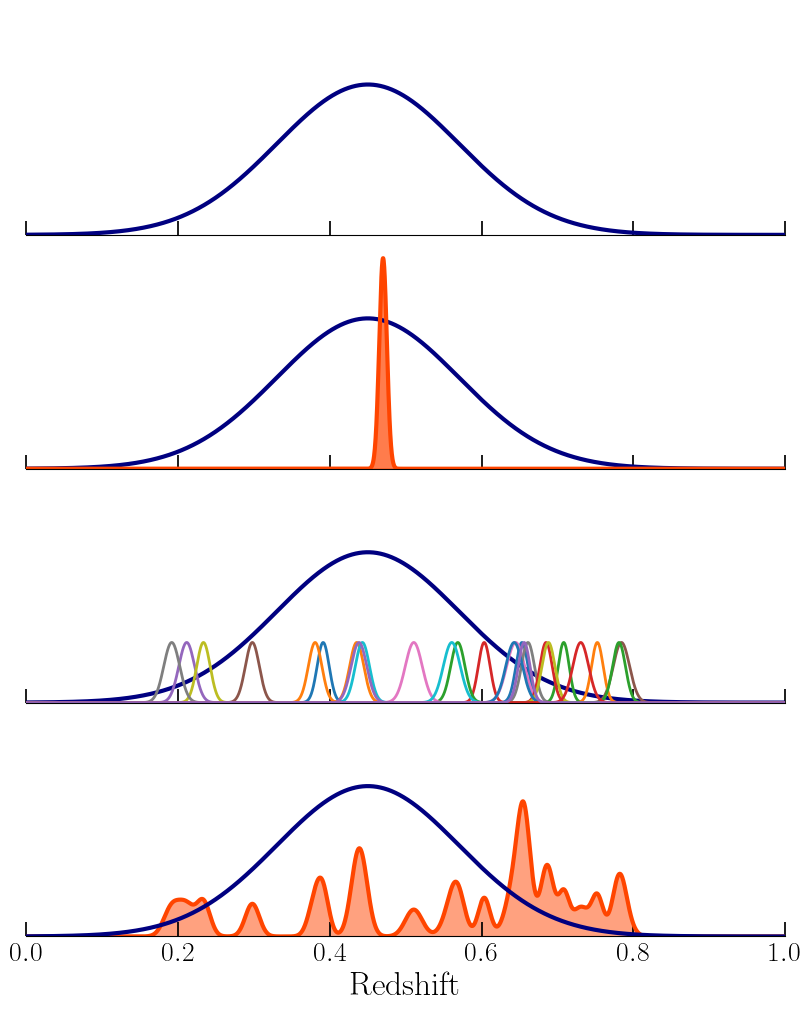

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

gwcolor = 'navy'
emcolor = 'orangered'
biglw = 3

# --------------------------------------------------
# Redshift grid
# --------------------------------------------------
z = np.linspace(0.0, 1.0, 3000)

fig, axes = plt.subplots(
    4, 1,
    figsize=(8, 10),
    sharex=True,
    constrained_layout=True
)

# ==================================================
# 1. Broad GW likelihood
# ==================================================
z_gw = 0.45
sigma_gw = 0.12

gw = norm.pdf(z, z_gw, sigma_gw)
gw /= gw.max()   # purely for visualization

# axes[0].fill_between(z, gw, alpha=0.5)
axes[0].plot(z, gw, lw=biglw, color=gwcolor)
axes[0].set_ylabel("")
axes[0].set_yticks([])
# axes[0].set_title("1. GW redshift likelihood")

# ==================================================
# 2. Add an EM counterpart
# ==================================================
sigma_em = 0.005
z_em = 0.47

em = norm.pdf(z, z_em, sigma_em)
em /= em.max() / 1.4

# axes[1].fill_between(z, gw, alpha=0.3, label="GW")
axes[1].plot(z, gw, lw=biglw, color=gwcolor)

axes[1].fill_between(
    z, em,
    alpha=0.7,
    color=emcolor)
axes[1].plot(z, em, lw=biglw, color=emcolor)

# axes[1].legend(frameon=False)
axes[1].set_yticks([])
# axes[1].set_title("2. GW likelihood + EM counterpart")

# ==================================================
# 3. Possible host galaxies
# ==================================================
rng = np.random.default_rng(42)

n_hosts = 25
host_means = rng.uniform(0.15, 0.8, n_hosts)
host_sigmas = rng.uniform(0.007, 0.012, n_hosts)

# axes[2].fill_between(z, gw, alpha=0.25)
axes[2].plot(z, gw, lw=biglw, color=gwcolor)

for mu, sig in zip(host_means, host_sigmas):
    g = norm.pdf(z, mu, sig)
    g /= g.max()
    axes[2].plot(z, 0.4 * g, lw=2)

axes[2].set_yticks([])
# axes[2].set_title("3. Candidate host galaxies")
# axes[2].legend(frameon=False)

# ==================================================
# 4. Construct the galaxy redshift prior
# ==================================================
prior = np.zeros_like(z)

for mu, sig in zip(host_means, host_sigmas):
    prior += norm.pdf(z, mu, sig)

# Proper normalization:
prior /= n_hosts * 8

axes[3].plot(z, prior, lw=biglw, color=emcolor)
axes[3].fill_between(z, prior, alpha=0.5, color=emcolor)

axes[3].plot(z, gw, lw=biglw, color='navy')

# # Optional: overlay individual hosts
# for mu, sig, w in zip(host_means, host_sigmas, weights):
#     g = w * norm.pdf(z, mu, sig)
#     g /= np.trapz(prior, z)
#     axes[3].plot(z, g, lw=0.7, alpha=0.3)

# axes[3].set_title("4. Galaxy redshift prior")
axes[3].set_yticks([])
axes[3].set_xlabel("Redshift")

for ax in axes:
    ax.set_xlim(0, 1)

for ax in axes:
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    
    ax.minorticks_off()
    ax.tick_params(axis='x', which='major', top=False)

    ax.set_ylim(0, 1.5)

plt.show()

# Filter data

In [6]:
gwtc2p1_path = '/home/lucas/Documents/PhD/gw_data/PEsamples_gwtc2p1'
gwtc3p0_path = '/home/lucas/Documents/PhD/gw_data/PEsamples_gwtc3p0'
gwtc4p0_path = '/home/lucas/Documents/PhD/gw_data/PEsamples_gwtc4p0'
gwtc5p0_path = '/home/lucas/Documents/PhD/gw_data/PEsamples_gwtc5p0'

filenames_gwtc2p1 = glob.glob(gwtc2p1_path + '/*mixed_nocosmo.h5')
filenames_gwtc3p0 = glob.glob(gwtc3p0_path + '/*mixed_nocosmo.h5')
filenames_gwtc4p0 = glob.glob(gwtc4p0_path + '/*combined*.hdf5')
filenames_gwtc5p0 = glob.glob(gwtc5p0_path + '/*combined*.hdf5')
print(len(filenames_gwtc2p1), len(filenames_gwtc3p0), len(filenames_gwtc4p0), len(filenames_gwtc5p0))

all_filenames = filenames_gwtc2p1 + filenames_gwtc3p0 + filenames_gwtc4p0 + filenames_gwtc5p0
print(f'Got {len(all_filenames)} GWs with PE results, from which the NS candidates still have to be removed and SNR/FAR may still be insufficient.')

gwkeys = []
for fname in filenames_gwtc2p1 + filenames_gwtc3p0:
    gwkey = fname.split('-')[-1].split('_PED')[0]
    gwkeys.append(gwkey)
for fname in filenames_gwtc4p0 + filenames_gwtc5p0:
    gwkey = fname.split('-')[-2]
    gwkeys.append(gwkey)
print(gwkeys)

54 36 86 104
Got 280 GWs with PE results, from which the NS candidates still have to be removed and SNR/FAR may still be insufficient.
['GW190828_065509', 'GW190630_185205', 'GW170104_101158', 'GW190916_200658', 'GW190527_092055', 'GW190929_012149', 'GW190924_021846', 'GW190828_063405', 'GW190917_114630', 'GW151226_033853', 'GW190412_053044', 'GW151012_095443', 'GW190514_065416', 'GW170608_020116', 'GW190413_134308', 'GW190910_112807', 'GW190814_211039', 'GW190602_175927', 'GW190725_174728', 'GW190425_081805', 'GW190521_030229', 'GW190708_232457', 'GW170809_082821', 'GW190517_055101', 'GW190701_203306', 'GW190720_000836', 'GW190731_140936', 'GW190512_180714', 'GW190805_211137', 'GW190925_232845', 'GW190503_185404', 'GW190728_064510', 'GW190403_051519', 'GW190803_022701', 'GW190719_215514', 'GW190513_205428', 'GW190707_093326', 'GW150914_095045', 'GW190727_060333', 'GW190930_133541', 'GW190926_050336', 'GW190421_213856', 'GW190408_181802', 'GW190413_052954', 'GW190519_153544', 'GW190620

In [7]:
ns_candidates = np.loadtxt('/home/lucas/Documents/PhD/gw_data/NSmergers.txt', dtype=str)
print(ns_candidates)

# Verification
ns_files = []
for file in all_filenames:
    for candidate in ns_candidates:
        if candidate in file:
            ns_files.append(file)
            gwkeys.remove(candidate)

# Remove NSs
all_filenames = [file for file in all_filenames if not file in ns_files]
print(f'Got {len(all_filenames)} GWs after removing NSs.')
print(f'Confirming removal of the GW names from list: {len(gwkeys)}')


['GW190814_211039' 'GW230518_125908' 'GW230529_181500' 'GW170817'
 'GW191219_163120' 'GW190425_081805' 'GW200115_042309' 'GW190917_114630'
 'GW200210_092254' 'GW200105_162426']
Got 271 GWs after removing NSs.
Confirming removal of the GW names from list: 271


# Get SNR and FAR

In [8]:
gwdat = pd.read_csv('/home/lucas/Documents/PhD/gw_data/events.csv')

snr_dict = {}
snr_list = []
far_dict = {}
far_list = []
for key in gwkeys:

    snr = gwdat['network_matched_filter_snr'][gwdat['name'] == key].to_numpy()
    far = gwdat['far'][gwdat['name'] == key].to_numpy()

    if len(snr) == 0:
        print(f'Could not find key {key}')

        newkey = key.split('_')[0]

        snr_newkey = gwdat['network_matched_filter_snr'][gwdat['name'] == newkey].to_numpy()
        far_newkey = gwdat['far'][gwdat['name'] == newkey].to_numpy()
        print(f'But {newkey} got snr: {snr_newkey}')
        print(f'But {newkey} got far: {far_newkey}')
        
        if len(snr_newkey) == 0:
            print(f'WARNING: {key} and {newkey} not found! Skipping!')

        else:

            snr_dict[key] = snr_newkey
            snr_list.append(snr_newkey)

            far_dict[key] = far_newkey
            far_list.append(far_newkey)

    else:
        snr_dict[key] = snr
        snr_list.append(snr)
        print(key, 'snr', snr)

        far_dict[key] = far
        far_list.append(far)
        print(key, 'far', far)
    print()

print(f'Confirming length of SNR dict: {len(snr_dict.keys())}')
print(f'Confirming length of FAR dict: {len(far_dict.keys())}')

GW190828_065509 snr [10.2]
GW190828_065509 far [3.5e-05]

GW190630_185205 snr [16.4]
GW190630_185205 far [1.e-05]

Could not find key GW170104_101158
But GW170104 got snr: [13.8]
But GW170104 got far: [nan]

GW190916_200658 snr [8.1]
GW190916_200658 far [4.7]

GW190527_092055 snr [8.]
GW190527_092055 far [0.23]

GW190929_012149 snr [9.7]
GW190929_012149 far [0.16]

GW190924_021846 snr [12.]
GW190924_021846 far [1.e-05]

GW190828_063405 snr [16.5]
GW190828_063405 far [1.e-05]

Could not find key GW151226_033853
But GW151226 got snr: [12.7]
But GW151226 got far: [nan]

Could not find key GW190412_053044
But GW190412 got snr: [19.8]
But GW190412 got far: [1.e-05]

Could not find key GW151012_095443
But GW151012 got snr: [9.3]
But GW151012 got far: [nan]

GW190514_065416 snr [8.]
GW190514_065416 far [2.8]

Could not find key GW170608_020116
But GW170608 got snr: [15.3]
But GW170608 got far: [nan]

GW190413_134308 snr [10.6]
GW190413_134308 far [0.18]

GW190910_112807 snr [14.5]
GW190910_11

In [9]:
far_thr = 1
snr_thr = 10

n = 0
below_thresh = []
for key in snr_dict.keys():
    run = get_run(key)
    
    if run in ['O3', 'O4']:
        if far_dict[key] > far_thr:
            below_thresh.append(key)
            continue
    elif run in ['O1', 'O2']:
        if snr_dict[key] < snr_thr:
            below_thresh.append(key)
            continue
    else:
        print('Huh?', key)
        
    n += 1

print(f'Got {n} GWs above our detection threshold.')
print(f'These {len(below_thresh)} events do not pass our threshold: {below_thresh}')


Got 256 GWs above our detection threshold.
These 15 events do not pass our threshold: ['GW190916_200658', 'GW151012_095443', 'GW190514_065416', 'GW190403_051519', 'GW190926_050336', 'GW190426_190642', 'GW191126_115259', 'GW200220_124850', 'GW191113_071753', 'GW191204_110529', 'GW200308_173609', 'GW200306_093714', 'GW200220_061928', 'GW200208_222617', 'GW200322_091133']


In [10]:
skip_these_files = []
for file in all_filenames:
    for key in below_thresh:
        if key in file:
            print(key, snr_dict[key], far_dict[key])
            skip_these_files.append(file)
            gwkeys.remove(key)

all_filenames = [file for file in all_filenames if not file in skip_these_files]
print(f'Got {len(all_filenames)} GWs after removing events below our detection threshold.')
print(f'Confirming length of key list: {len(gwkeys)}')


GW190916_200658 [8.1] [4.7]
GW151012_095443 [9.3] [nan]
GW190514_065416 [8.] [2.8]
GW190403_051519 [7.6] [7.7]
GW190926_050336 [8.1] [1.1]
GW190426_190642 [8.7] [4.1]
GW191126_115259 [8.3] [3.2]
GW200220_124850 [8.5] [30.]
GW191113_071753 [7.9] [26.]
GW191204_110529 [8.9] [3.3]
GW200308_173609 [4.7] [2.4]
GW200306_093714 [7.8] [24.]
GW200220_061928 [7.2] [6.8]
GW200208_222617 [7.4] [4.8]
GW200322_091133 [4.5] [140.]
Got 256 GWs after removing events below our detection threshold.
Confirming length of key list: 256


In [11]:
# Write PE samples paths to .json file
PE_json_outpath = '/home/lucas/Documents/PhD/gw_data/reweighted-gwtc5/real_PEsamples_gwtc5.json'

PEdict = {}
for key, fname in zip(gwkeys, all_filenames):
    if key not in fname:
        print(key, fname)
    
    PEdict[key] = fname

with open(PE_json_outpath, 'w') as outfile:
    json.dump(PEdict, outfile)


# Check for PE priors hdf5 files

In [12]:
with open(PE_json_outpath, "r") as f:
    PEpaths = json.load(f)

# 'C00:Mixed', 'C01:Mixed', 'C00:IMRPhenomXO4a', 'C00:IMRPhenomXPHM-SpinTaylor', 'C00:NRSur7dq4',
# default_approximants = ['C00:Mixed', 'C01:Mixed', 'C00:IMRPhenomXO4a', 'C00:IMRPhenomXPHM-SpinTaylor', 'C00:NRSur7dq4', 'C01:IMRPhenomXPHM', 'C01:SEOBNRv4PHM', 'C00:SEOBNRv5PHM' ]

approxdict = {}
nopriors = []
no_dlpriors = []
for key in PEpaths.keys():
    path = PEpaths[key]

    # if key not in ['GW231118_005626']:
    #     continue

    with h5py.File(path, 'r') as f:

        got_priors = False
        apx = []
        for approximant in list(f.keys()):
            if approximant in ['history', 'version']:
                continue
            
            try:
                prior = f[approximant]['priors']
                got_priors = True
                apx.append(approximant)
            except KeyError:
                # print(f'{key} does not have column priors for approximant {approximant}. Got: {list(f[approximant].keys())}')
                # nopriors.append(key)
                continue
        
        if not got_priors:
            nopriors.append((key))
            continue

        # print(f'{key} has priors for: {apx}')
        
        got_dlprior = False
        apx_with_dlprior = []
        for approximant in apx:
            prior = f[approximant]['priors']
            try:
                analytic_prior = prior['analytic']['luminosity_distance']
                got_dlprior = True
                apx_with_dlprior.append(approximant)
                # print(key, approximant)
                print(list(analytic_prior))
                # print(list(analytic_prior['chirp_mass']))
                # print(list(analytic_prior['luminosity_distance']))
                # print(list(analytic_prior['mass_1']))
                # print(list(analytic_prior['mass_2']))
                # print()
            except KeyError:
                continue
        
        print(f'{key} has dL prior for: {apx_with_dlprior}')
        print()

        approxdict[key] = apx_with_dlprior
        
        if not got_dlprior:
            no_dlpriors.append(key)

print(f'Summary: no priors at all for {nopriors}. \nNo dLpriors for {no_dlpriors}.')


[np.bytes_(b"PowerLaw(alpha=2, minimum=10, maximum=10000, name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)")]
GW190828_065509 has dL prior for: ['C01:IMRPhenomXPHM']

[np.bytes_(b"PowerLaw(alpha=2, minimum=100, maximum=10000, name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)")]
GW190630_185205 has dL prior for: ['C01:IMRPhenomXPHM']

[np.bytes_(b"PowerLaw(alpha=2, minimum=100, maximum=10000, name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)")]
GW170104_101158 has dL prior for: ['C01:IMRPhenomXPHM']

[np.bytes_(b"PowerLaw(alpha=2, minimum=100, maximum=10000, name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)")]
GW190527_092055 has dL prior for: ['C01:IMRPhenomXPHM']

[np.bytes_(b"PowerLaw(alpha=2, minimum=100, maximum=10000, name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)")]
GW190929_012149 has dL prior for: ['C01:IMRPhenomXPHM']

GW190924_021846 has dL pri

In [13]:
# Check that IMRPhenomXPHM waveform approximant is present for all events

a = 'C00:IMRPhenomXPHM-SpinTaylor'  # ['C00:IMRPhenomXPHM-SpinTaylor', 'C00:SEOBNRv5PHM']
b = 'C01:IMRPhenomXPHM'
c = 'C01:IMRPhenomXPHM-SpinTaylor'

for key in approxdict.keys():
    
    if len(approxdict[key]) == 1:
        if b not in approxdict[key]:
            print(key, approxdict[key])
    
    if len(approxdict[key]) > 1:
        # print(key, approxdict[key])
        if (a not in approxdict[key]) and (c not in approxdict[key]):
            print(key, approxdict[key])


In [14]:
# Store approximants and PEpriors

prior_dict = {}
for i, key in enumerate(PEpaths.keys()):
    path = PEpaths[key]

    ### Checked manually: dl^2 prior with 'C01:IMRPhenomXPHM' waveform should be fine for all events missing analytical PE prior. ###
    if key in no_dlpriors:
        with h5py.File(PEpaths['GW190828_065509'], 'r') as f:
            prior = list(f['C01:IMRPhenomXPHM']['priors']['analytic']['luminosity_distance'])
        prior_dict[key] = ('C01:IMRPhenomXPHM', prior)
    ########################
    
    else:
        with h5py.File(path, 'r') as f:
            try:
                prior = list(f['C01:IMRPhenomXPHM']['priors']['analytic']['luminosity_distance'])
                prior_dict[key] = ('C01:IMRPhenomXPHM', prior)
            except:
                try:
                    prior = list(f['C01:IMRPhenomXPHM-SpinTaylor']['priors']['analytic']['luminosity_distance'])
                    prior_dict[key] = ('C01:IMRPhenomXPHM-SpinTaylor', prior)
                except:
                    prior = list(f['C00:IMRPhenomXPHM-SpinTaylor']['priors']['analytic']['luminosity_distance'])
                    prior_dict[key] = ('C00:IMRPhenomXPHM-SpinTaylor', prior)

    print(prior_dict[key][1], key)
# prior_dict_outpath = '/home/lucas/Documents/PhD/gw_data/prior_dict'
# with open(prior_dict_outpath, 'w') as outfile:
#     json.dump(prior_dict, outfile)


[np.bytes_(b"PowerLaw(alpha=2, minimum=10, maximum=10000, name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)")] GW190828_065509
[np.bytes_(b"PowerLaw(alpha=2, minimum=100, maximum=10000, name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)")] GW190630_185205
[np.bytes_(b"PowerLaw(alpha=2, minimum=100, maximum=10000, name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)")] GW170104_101158
[np.bytes_(b"PowerLaw(alpha=2, minimum=100, maximum=10000, name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)")] GW190527_092055
[np.bytes_(b"PowerLaw(alpha=2, minimum=100, maximum=10000, name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)")] GW190929_012149
[np.bytes_(b"PowerLaw(alpha=2, minimum=10, maximum=10000, name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)")] GW190924_021846
[np.bytes_(b"PowerLaw(alpha=2, minimum=10, maximum=10000, name='luminosity_dis

# Reweight individual GW redshift posteriors

In [15]:
# First check the hyperparameters posteriors. We take the MAP values of the madau_dickinson redshift model (which is consistent with, but not equal to their default model) and broken PL + 2P mass model.

# filename = "/home/lucas/Documents/PhD/gwtc5_updated_default_mmax_mass_TwoPeakBrokenPowerLawSmoothedMassDistribution_redshift_PowerLawRedshift_magnitude_iid_spin_magnitude_gaussian_tilt_iid_spin_orientation_popsummary_result.h5"
filename = "/home/lucas/Documents/PhD/popsummary_files/gwtc5_updated_madau_dickinson_mmax_mass_TwoPeakBrokenPowerLawSmoothedMassDistribution_redshift_MadauDickinsonRedshift_magnitude_iid_spin_magnitude_gaussian_tilt_iid_spin_orientation_popsummary_result.h5"
result = PopulationResult(fname=filename)

# # Relevant hyperparameters
# mass_hyperparam = ['alpha_1', 'alpha_2', 'break_mass', 'mpp_1', 'sigpp_1', 'mpp_2', 'sigpp_2', 'mlow_1', 'delta_m_1', 'lam_0', 'lam_1', 'mmax',
#                     'beta', 'mlow_2', 'delta_m_2']
# z_hyperparams = ['z_peak', 'gamma', 'kappa']
# all_hyperparams = z_hyperparams + mass_hyperparam

# # MAP values of the hyperparameters
# df = pd.DataFrame(result.get_hyperparameter_samples(), columns=result.get_metadata("hyperparameters"))
# hyperparams = df.iloc[(df.log_likelihood + df.log_prior).idxmax()]

# # Redshift hyperparams
# kappa = hyperparams.loc['kappa']
# gamma = hyperparams.loc['gamma']
# z_peak = hyperparams.loc['z_peak']
# print(gamma, 1+z_peak, kappa)

# def merger_rate_lowmetallicity_sfr(z, Z=0.3):
#     'Fishbach+2018'
#     fZ = gammaincc(0.84, (Z**2) * 10**(0.3 * z))
#     return merger_rate_madau_dickinson(z) * fZ

# z_ax = np.linspace(0, 10, 1024+1)
# plt.figure(figsize=(8,6))
# plt.plot(z_ax, merger_rate_madau_dickinson(z_ax) / romb(merger_rate_madau_dickinson(z_ax), dx=np.diff(z_ax)[0]), label='Madau-Dickinson')
# plt.plot(z_ax, merger_rate_madau_dickinson(z_ax, b=gamma, c=1+z_peak, d=kappa) / romb(merger_rate_madau_dickinson(z_ax, b=gamma, c=1+z_peak, d=kappa), dx=np.diff(z_ax)[0]), label='LVK MAP')
# plt.plot(z_ax, merger_rate_lowmetallicity_sfr(z_ax, Z=0.3) / romb(merger_rate_lowmetallicity_sfr(z_ax, Z=0.3), dx=np.diff(z_ax)[0]), label='Low-Z SFR')
# # plt.plot(z_ax, get_agn_outofcat_pop('46.5')(z_ax), label='46.5')
# # plt.plot(z_ax, get_agn_outofcat_pop('44.5')(z_ax), label='44.5')
# plt.legend()
# # plt.loglog()
# plt.xlabel('Redshift')
# plt.ylabel('PDF')
# plt.semilogy()
# plt.xlim(0, 1.5)
# plt.ylim(1e-2, 1e0)
# plt.show()


# for hyperparamlabel in all_hyperparams:

#     param = result.get_hyperparameter_samples(hyperparameters=[hyperparamlabel])
#     med = np.median(param)
#     # print(f'Median {hyperparamlabel} = {med}')
#     print(f'MAP {hyperparamlabel} = {hyperparams.loc[hyperparamlabel]}')

#     plt.figure()
#     h, _, _ = plt.hist(param, bins=30, density=True)
#     plt.vlines(med, 0, 1.1 * np.max(h), color='black')
#     plt.vlines(hyperparams.loc[hyperparamlabel], 0, 1.1 * np.max(h), color='red')
#     plt.xlabel(hyperparamlabel)
#     plt.show()


opening existing popsummary file: /home/lucas/Documents/PhD/popsummary_files/gwtc5_updated_madau_dickinson_mmax_mass_TwoPeakBrokenPowerLawSmoothedMassDistribution_redshift_MadauDickinsonRedshift_magnitude_iid_spin_magnitude_gaussian_tilt_iid_spin_orientation_popsummary_result.h5


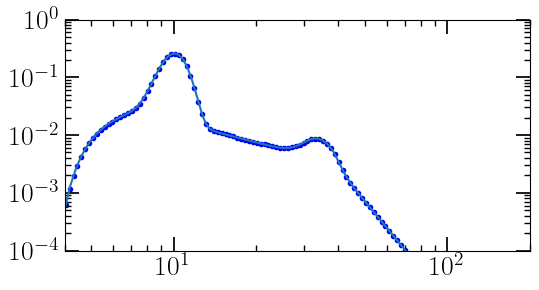

In [16]:
# MAP values
alpha_1 = hyperparams.loc['alpha_1']
alpha_2 = hyperparams.loc['alpha_2']
break_mass = hyperparams.loc['break_mass']
mpp_1 = hyperparams.loc['mpp_1']
sigpp_1 = hyperparams.loc['sigpp_1']
mpp_2 = hyperparams.loc['mpp_2']
sigpp_2 = hyperparams.loc['sigpp_2']
mlow_1 = hyperparams.loc['mlow_1']
delta_m_1 = hyperparams.loc['delta_m_1']
lam_0 = hyperparams.loc['lam_0']
lam_1 = hyperparams.loc['lam_1']
mmax = hyperparams.loc['mmax']
beta = hyperparams.loc['beta']
mlow_2 = hyperparams.loc['mlow_2']
delta_m_2 = hyperparams.loc['delta_m_2']

b = (break_mass - mlow_1) / (mmax - mlow_1)
lambda_g = 1 - lam_0
lambda_g_0 = lam_1 / lambda_g

masspop_MAP = BBH_broken_powerlaw_multi_peak_gaussian_m1m2(alpha_1=alpha_1,
                                                        alpha_2=alpha_2,
                                                        b=b,   # Calc from break mass: break_point = mminbh + b * (mmaxbh - mminbh)
                                                        beta=beta,
                                                        mminbh=mlow_1,
                                                        mmaxbh=mmax,
                                                        lambda_g=lambda_g,  # Fraction in both peaks
                                                        lambda_g_0=lambda_g_0,  # Fraction in lower peak
                                                        mu_g_0=mpp_1,
                                                        sigma_g_0=sigpp_1,
                                                        mu_g_1=mpp_2,
                                                        sigma_g_1=sigpp_2,
                                                        delta_m=delta_m_1,
                                                        mlow_2=mlow_2,
                                                        delta_m_2=delta_m_2)

fig, ax = plt.subplots(figsize=(6,3))
marr = torch.as_tensor(np.linspace(3, 200, 1000))
ax.plot(marr, masspop_MAP.mdis['mass_1'].prob(marr))
# ax.plot(marr, masspop.mdis['mass_2'].prob(marr))

N = 128+1
m1 = np.geomspace(3, 200, N)
for m1_val in m1:
    m2 = np.linspace(3, m1_val, N)

    masspop_eval = masspop_MAP.joint_prob(np.full_like(m2, m1_val), m2).detach().cpu().numpy()
    m1_marginalprob = romb(masspop_eval, dx=np.diff(m2)[0])

    ax.scatter(m1_val, m1_marginalprob, marker='.', color='blue')

# m2 = np.geomspace(3, 200, N)
# for m2_val in m2:
#     m1 = np.geomspace(m2_val, 200, N)

#     masspop_eval = masspop.joint_prob(m1, np.full_like(m1, m2_val)).detach().cpu().numpy()
#     m2_marginalprob = romb(masspop_eval * m1, dx=np.diff(np.log10(m1))[0])

#     ax.scatter(m2_val, m2_marginalprob, marker='.', color='red')

ax.loglog()
ax.set_xlim(4e0, 2e2)
ax.set_ylim(1e-4, 1e0)
plt.show()


In [17]:
# for i in list(df.columns):
#     if i[:3] == 'var':
#         continue
#     elif i[:4] == 'ln_b':
#         continue
#     print(i)

# # print(dir(result))
# # print(result.get_metadata())

In [18]:
from scipy.stats import truncnorm


def truncated_normal_pdf(x, mu, sigma, low, high):
    """
    PDF of a truncated normal.
    """
    a = (low - mu) / sigma
    b = (high - mu) / sigma
    return truncnorm.pdf(x, a=a, b=b, loc=mu, scale=sigma)


def spin_magnitude_pdf(chi1, chi2, mu_chi, sigma_chi):
    """
    Eq. (B15)
    """
    p1 = truncated_normal_pdf(chi1, mu_chi, sigma_chi, 0.0, 1.0)
    p2 = truncated_normal_pdf(chi2, mu_chi, sigma_chi, 0.0, 1.0)
    return p1 * p2


def spin_tilt_pdf(cost1, cost2, mu_spin, sigma_spin, xi_spin):
    """
    Eq. (B16)
    """
    aligned = (
        truncated_normal_pdf(cost1, mu_spin, sigma_spin, -1.0, 1.0)
        * truncated_normal_pdf(cost2, mu_spin, sigma_spin, -1.0, 1.0)
    )

    isotropic = 0.25

    return xi_spin * aligned + (1.0 - xi_spin) * isotropic


def spin_azimuthal_pdf(phi1, phi2):
    """
    Uniform azimuthal angles:
        phi1, phi2 ~ Uniform(0, 2π)
    """
    return np.ones_like(phi1) / (2 * np.pi) ** 2


def joint_spin_pdf(
    chi1,
    chi2,
    cost1,
    cost2,
    mu_chi,
    sigma_chi,
    mu_spin,
    sigma_spin,
    xi_spin,
):
    """
    Joint spin distribution
    p(chi1, chi2, cos1, cos2)
    """
    return (
        spin_magnitude_pdf(chi1, chi2, mu_chi, sigma_chi)
        * spin_tilt_pdf(cost1, cost2, mu_spin, sigma_spin, xi_spin)
    )


def log_joint_spin_pdf(
    phi1,
    phi2,
    chi1,
    chi2,
    cost1,
    cost2,
    mu_chi,
    sigma_chi,
    mu_spin,
    sigma_spin,
    xi_spin,
):
    """
    Joint spin distribution
    p(chi1, chi2, cos1, cos2)
    """
    return (
        np.log(spin_magnitude_pdf(chi1, chi2, mu_chi, sigma_chi))
        + np.log(spin_tilt_pdf(cost1, cost2, mu_spin, sigma_spin, xi_spin) * np.sin(np.arccos(cost1)) * np.sin(np.arccos(cost2)))
        + np.log(spin_azimuthal_pdf(phi1, phi2))
    )


In [19]:
# rate = result.get_hyperparameter_samples(hyperparameters=['rate']).squeeze()  # 1/Gpc^3 1/year

# # REDSHIFT
# try:
#     lamb = result.get_hyperparameter_samples(hyperparameters=['lamb'])
# except:
#     print(f'Could not load lamb. Correct if this is the MD hyperparam file: {filename}')

# # SPIN
# mu_chi = result.get_hyperparameter_samples(hyperparameters=['mu_chi']).squeeze()
# sigma_chi = result.get_hyperparameter_samples(hyperparameters=['sigma_chi']).squeeze()
# mu_spin = result.get_hyperparameter_samples(hyperparameters=['mu_spin']).squeeze()
# sigma_spin = result.get_hyperparameter_samples(hyperparameters=['sigma_spin']).squeeze()
# xi_spin = result.get_hyperparameter_samples(hyperparameters=['xi_spin']).squeeze()

# # MASS
# alpha_1 = result.get_hyperparameter_samples(hyperparameters=['alpha_1']).squeeze()
# alpha_2 = result.get_hyperparameter_samples(hyperparameters=['alpha_2']).squeeze()
# break_mass = result.get_hyperparameter_samples(hyperparameters=['break_mass']).squeeze()
# mpp_1 = result.get_hyperparameter_samples(hyperparameters=['mpp_1']).squeeze()
# sigpp_1 = result.get_hyperparameter_samples(hyperparameters=['sigpp_1']).squeeze()
# mpp_2 = result.get_hyperparameter_samples(hyperparameters=['mpp_2']).squeeze()
# sigpp_2 = result.get_hyperparameter_samples(hyperparameters=['sigpp_2']).squeeze()
# mlow_1 = result.get_hyperparameter_samples(hyperparameters=['mlow_1']).squeeze()
# delta_m_1 = result.get_hyperparameter_samples(hyperparameters=['delta_m_1']).squeeze()
# lam_0 = result.get_hyperparameter_samples(hyperparameters=['lam_0']).squeeze()
# lam_1 = result.get_hyperparameter_samples(hyperparameters=['lam_1']).squeeze()
# mmax = result.get_hyperparameter_samples(hyperparameters=['mmax']).squeeze()
# beta = result.get_hyperparameter_samples(hyperparameters=['beta']).squeeze()
# mlow_2 = result.get_hyperparameter_samples(hyperparameters=['mlow_2']).squeeze()
# delta_m_2 = result.get_hyperparameter_samples(hyperparameters=['delta_m_2']).squeeze()

# b = (break_mass - mlow_1) / (mmax - mlow_1)
# lambda_g = 1 - lam_0
# lambda_g_0 = lam_1 / lambda_g

# # EVOLVE RATE FROM R_0 TO R(Z)
# zeval = 0.2
# redshift_factor = (1 + zeval)**(lamb)

# # SELECTION EFFECTS
# far_thr = 1
# snr_thr = 10
# sel = ((snr_inject > snr_thr) | (far_inject < far_thr))

# z_sel = redshift_inject[sel]
# m1s_sel = mass1_source_inject[sel]
# m2s_sel = mass2_source_inject[sel]
# cost1_sel = np.cos(spin1theta[sel])
# cost2_sel = np.cos(spin2theta[sel])
# spin1r_sel = spin1r[sel]
# spin2r_sel = spin2r[sel]
# spin1phi_sel = spin1phi[sel]
# spin2phi_sel = spin2phi[sel]

# lnz_sel = np.log(COSMO.differential_comoving_volume(z_sel).to(u.Gpc**3 / u.sr).value * 4 * np.pi / (1 + z_sel))
# w_sel = weights[sel]
# lnprob_sel = lnprob[sel]

# def lnz_pdf(z, lamb):
#     unnorm = COSMO.differential_comoving_volume(z).to(u.Gpc**3 / u.sr).value * 4 * np.pi / (1 + z) * (1 + z)**lamb
#     unnorm_interp = interp1d(z, unnorm, fill_value=0, bounds_error=False)
#     normax = np.linspace(0, 10, 1024+1)
#     return unnorm_interp(z) / romb(unnorm_interp(normax), dx=np.diff(normax)[0])

# N_det = 256
# Tyr = (total_analysis_time * u.s).to(u.year).value

# marr = torch.as_tensor(np.geomspace(3, 200, 200))
# # marginalprobs = np.zeros((len(alpha_1[:1000]), len(marr)))
# # for i in tqdm( range(len(alpha_1[:1000])) ):
# marginalprobs = np.zeros((len(alpha_1), len(marr)))
# drdm1 = np.zeros((len(alpha_1), len(marr)))
# drdm1_nosamp = np.zeros((len(alpha_1), len(marr)))
# # factors = np.zeros(len(alpha_1))
# for i in tqdm( range(len(alpha_1)) ):

#     log_p_spin = log_joint_spin_pdf(
#         phi1=spin1phi_sel, 
#         phi2=spin2phi_sel,
#         chi1=spin1r_sel,
#         chi2=spin2r_sel,
#         cost1=cost1_sel,
#         cost2=cost2_sel,
#         mu_chi=mu_chi[i],
#         sigma_chi=sigma_chi[i],
#         mu_spin=mu_spin[i],
#         sigma_spin=sigma_spin[i],
#         xi_spin=xi_spin[i],
#     )


#     masspop = BBH_broken_powerlaw_multi_peak_gaussian_m1m2(
#                                                             alpha_1=float(alpha_1[i]),
#                                                             alpha_2=float(alpha_2[i]),
#                                                             b=float(b[i]),
#                                                             beta=float(beta[i]),
#                                                             mminbh=float(mlow_1[i]),
#                                                             mmaxbh=float(mmax[i]),
#                                                             lambda_g=float(lambda_g[i]),
#                                                             lambda_g_0=float(lambda_g_0[i]),
#                                                             mu_g_0=float(mpp_1[i]),
#                                                             sigma_g_0=float(sigpp_1[i]),
#                                                             mu_g_1=float(mpp_2[i]),
#                                                             sigma_g_1=float(sigpp_2[i]),
#                                                             delta_m=float(delta_m_1[i]),
#                                                             mlow_2=float(mlow_2[i]),
#                                                             delta_m_2=float(delta_m_2[i]),
#                                                         )
#     masspop_eval = masspop.mdis['mass_1'].prob(marr) * redshift_factor[i]


#     E_i = np.random.gamma(shape=N_det, scale=1.0)
#     # lnp_sel = np.ones_like(m1s_sel)

#     lnp_sel = masspop.log_joint_prob(m1s_sel, m2s_sel).detach().cpu().numpy() + lnz_sel + lamb[i] * np.log(1 + z_sel) + log_p_spin
#     # lnp_sel = masspop.log_joint_prob(m1s_sel, m2s_sel).detach().cpu().numpy() + np.log(lnz_pdf(z_sel, lamb[i])) + log_p_spin  # Using normalized redshift PDF
#     MC_sum = np.sum( w_sel * np.exp(lnp_sel - lnprob_sel) ) / total_generated
#     # print(MC_sum)

#     R_0 = E_i / Tyr / (MC_sum)
#     # print(R_0, rate[i])
#     # factors[i] = rate[i] / R_0
    
#     marginalprobs[i, :] = masspop_eval
#     # drdm1[i,:] = rate[i] * masspop_eval
#     drdm1[i,:] = R_0 * masspop_eval
#     drdm1_nosamp[i,:] = N_det / Tyr / (MC_sum) * masspop_eval  # Do not sample E_i, see if that reproduces the LVK errors better


In [20]:
# drdm1_LVK = (marginalprobs.T * rate).T

# fig, ax = plt.subplots(figsize=(12, 6))

# # ax.plot(torch.as_tensor(np.geomspace(3, 200, 1000)), masspop_MAP.mdis['mass_1'].prob(torch.as_tensor(np.geomspace(3, 200, 1000))), label='MAP')
# ax.plot(marr, np.median(drdm1_LVK, axis=0), color='green', label='LVK')
# ax.fill_between(marr, np.quantile(drdm1_LVK, q=0.05, axis=0), np.quantile(drdm1_LVK, q=0.95, axis=0), color='green', alpha=0.3)
# ax.plot(marr, np.median(drdm1, axis=0), color='red', label='Sampling E_i')
# ax.fill_between(marr, np.quantile(drdm1, q=0.05, axis=0), np.quantile(drdm1, q=0.95, axis=0), color='red', alpha=0.3)
# ax.plot(marr, np.median(drdm1_nosamp, axis=0), color='blue', label='N_det')
# ax.fill_between(marr, np.quantile(drdm1_nosamp, q=0.05, axis=0), np.quantile(drdm1_nosamp, q=0.95, axis=0), color='blue', alpha=0.3)
# ax.loglog()
# ax.set_xlim(4e0, 200)
# ax.set_ylim(0.003, 50)
# ax.set_xlabel(r'Primary mass [$\mathrm{M_{\odot}}$]')
# ax.set_ylabel(r'Rate at z=0.2')
# plt.legend()
# plt.show()

# fig, ax = plt.subplots(figsize=(12, 6))
# ax.plot(marr, np.median(drdm1_LVK, axis=0) - np.median(drdm1, axis=0), color='red', label='Sampling')
# ax.plot(marr, np.median(drdm1_LVK, axis=0) - np.median(drdm1_nosamp, axis=0), color='blue', label='fixed')
# # ax.fill_between(marr, np.quantile(drdm1_LVK, q=0.05, axis=0), np.quantile(drdm1_LVK, q=0.95, axis=0), color='green', alpha=0.3)
# # ax.plot(marr, np.median(drdm1, axis=0), color='red', label='Sampling E_i')
# # ax.fill_between(marr, np.quantile(drdm1, q=0.05, axis=0), np.quantile(drdm1, q=0.95, axis=0), color='red', alpha=0.3)
# # ax.plot(marr, np.median(drdm1_nosamp, axis=0), color='blue', label='N_det')
# # ax.fill_between(marr, np.quantile(drdm1_nosamp, q=0.05, axis=0), np.quantile(drdm1_nosamp, q=0.95, axis=0), color='blue', alpha=0.3)
# ax.semilogx()
# ax.set_xlim(4e0, 200)
# ax.set_ylim(0, 0.15)
# ax.set_xlabel(r'Primary mass [$\mathrm{M_{\odot}}$]')
# ax.set_ylabel(r'Difference with LVK')
# plt.legend()
# plt.show()


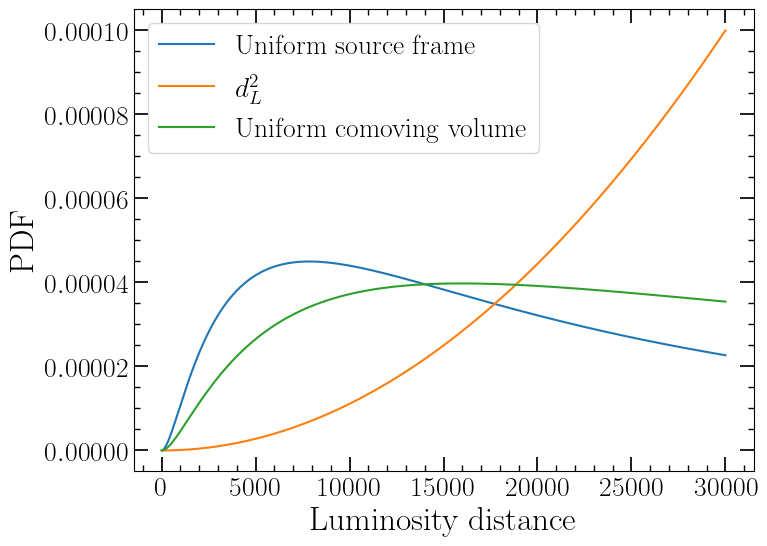

In [21]:
unif_volume_PEprior = bilby.gw.prior.PowerLaw(alpha=2, minimum=10, maximum=30000, name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)
unif_comoving_volume_PEprior = bilby.gw.prior.UniformComovingVolume(minimum=10.0, maximum=30000, cosmology=LambdaCDM(name=None, H0=67.9, Om0=0.3065, Ode0=0.6935, Tcmb0=0., Neff=3.04, m_nu=None, Ob0=None), name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)
unif_source_frame_PEprior = bilby.gw.prior.UniformSourceFrame(minimum=10.0, maximum=30000, cosmology=LambdaCDM(name=None, H0=67.9, Om0=0.3065, Ode0=0.6935, Tcmb0=0., Neff=3.04, m_nu=None, Ob0=None), name='luminosity_distance', latex_label='$d_L$', unit='Mpc', boundary=None)

dd = np.linspace(10, 30000, 1024+1)
zz = fast_z_at_value(COSMO.luminosity_distance, dd * u.Mpc)
plt.figure(figsize=(8,6))
plt.plot(dd, unif_source_frame_PEprior.prob(dd), label='Uniform source frame')
plt.plot(dd, unif_volume_PEprior.prob(dd), label=r'$d_L^2$')
plt.plot(dd, unif_comoving_volume_PEprior.prob(dd), label='Uniform comoving volume')
plt.legend()
plt.xlabel('Luminosity distance')
plt.ylabel('PDF')
plt.show()


In [22]:
namespace = {
    "bilby": bilby,
    "PowerLaw": bilby.gw.prior.PowerLaw,
    "LambdaCDM": LambdaCDM,
}

def prior_from_bytes(x):
    s = x.decode() if isinstance(x, bytes) else str(x)
    return eval(s, {"__builtins__": {}}, namespace)


def jacobian(z):
    dl = COSMO.luminosity_distance(z).value
    H_z = COSMO.H(z).value
    return (1 + z)**2 * ddl_dz(dl, z, H_z)


def get_z_m1_m2_PEprior_sourceframe(prior, dl_samps, z_samps):
    PEprior_detframe = prior.prob(dl_samps)  # pi_PE(dl, m1d, m2d)
    PEprior_sourceframe = PEprior_detframe * jacobian(z_samps)  # pi_PE(z, m1s, m2s) = pi_PE(dl, m1d, m2d) |ddl/dz * dm1d/dm1s * dm2d/dm2s| = pi_PE(dl, m1d, m2d) * (1 + z)**2 * |ddl/dz|
    return PEprior_sourceframe


def reweight_samps(samps, weights, size):
    w = weights / np.sum(weights)
    neff = 1.0 / np.sum(w**2)
    if neff < 0.1 * len(samps):
        print(f"WARNING: effective sample size is only {neff:.0f}/{len(samps)} ({neff/len(samps):.1%})")
    idx = np.random.choice(len(samps), p=w, size=size, replace=True)
    return samps[idx], idx


def get_reweighted_z_samples(posterior_samples, prior, target_prior, masspop=masspop_MAP, size=5000):
    dl_samps = posterior_samples['luminosity_distance']
    z_samps = posterior_samples['redshift']
    m1s_samps = posterior_samples['mass_1_source']
    m2s_samps = posterior_samples['mass_2_source']

    PEprior_sourceframe = get_z_m1_m2_PEprior_sourceframe(prior, dl_samps, z_samps)
    target_PEprior_sourceframe = get_z_m1_m2_PEprior_sourceframe(target_prior, dl_samps, z_samps)

    z_samps_dlprior_reweight, _ = reweight_samps(z_samps, weights = target_PEprior_sourceframe / PEprior_sourceframe, size=size)
    z_samps_full_reweight, full_reweight_idx = reweight_samps(z_samps, weights = masspop.joint_prob(m1s_samps, m2s_samps).detach().cpu().numpy() * target_PEprior_sourceframe / PEprior_sourceframe, size=size)

    w = masspop.joint_prob(m1s_samps, m2s_samps).detach().cpu().numpy() * target_PEprior_sourceframe / PEprior_sourceframe
    w /= np.sum(w)
    Neff = 1 / np.sum(w**2)
    # print("N =", len(w))
    # print("Neff =", Neff)
    # print("Neff/N =", Neff/len(w))
    # print("max weight =", np.max(w))

    return z_samps, z_samps_dlprior_reweight, z_samps_full_reweight, full_reweight_idx


In [23]:
from scipy.spatial.distance import jensenshannon

def js_distance(samples1, samples2, bins=100):
    lo = min(np.min(samples1), np.min(samples2))
    hi = max(np.max(samples1), np.max(samples2))

    p, _ = np.histogram(samples1, bins=bins, range=(lo, hi), density=True)
    q, _ = np.histogram(samples2, bins=bins, range=(lo, hi), density=True)

    # normalize
    p = p / p.sum()
    q = q / q.sum()

    return jensenshannon(p, q)


In [24]:
NSAMPS = int(1e4)

with open(PE_json_outpath, "r") as f:
    PEpaths = json.load(f)

target_prior = unif_comoving_volume_PEprior
for key in tqdm(prior_dict.keys()):

    run = get_run(key)
    # if run != 'O4':
    #     continue

    # if key.split('_')[0] != 'GW190521':
    #     continue

    # if key not in no_dlpriors:
    #     continue

    approximant, prior = prior_dict[key]
    prior = prior_from_bytes(prior[0])

    path = PEpaths[key]
    
    with h5py.File(path, 'r') as f:
        posterior_samples = f[approximant]['posterior_samples']
        z_samps, z_samps_dlprior_reweight, z_samps_full_reweight, full_reweight_idx = get_reweighted_z_samples(posterior_samples, prior, target_prior=target_prior, masspop=masspop_MAP, size=NSAMPS)
        has_mixed = False

        try:
            posterior_samples = f['C01:Mixed']['posterior_samples']
            z_samps_mixed, z_samps_dlprior_reweight_mixed, z_samps_full_reweight_mixed, full_reweight_idx = get_reweighted_z_samples(posterior_samples, prior, target_prior=target_prior, masspop=masspop_MAP, size=NSAMPS)
            dl_samps_full_reweight_mixed = COSMO.luminosity_distance(z_samps_full_reweight_mixed).value
            has_mixed = True
        except Exception as e:
            try:
                posterior_samples = f['C00:Mixed']['posterior_samples']
                z_samps_mixed, z_samps_dlprior_reweight_mixed, z_samps_full_reweight_mixed, full_reweight_idx = get_reweighted_z_samples(posterior_samples, prior, target_prior=target_prior, masspop=masspop_MAP, size=NSAMPS)
                dl_samps_full_reweight_mixed = COSMO.luminosity_distance(z_samps_full_reweight_mixed).value
                has_mixed = True
            except Exception as e:
                print(f'No mixed samples for {key}')
        
        if has_mixed:
            d = js_distance(z_samps_full_reweight, z_samps_full_reweight_mixed)
            if d > 0.15:
                print(f'JS divergence: {d}')
                
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
                plt.suptitle(f'{key}', fontsize=30)
                if has_mixed:
                    ax1.hist(dl_samps_full_reweight_mixed, density=True, bins=100, histtype='step', linewidth=1, label='Mixed reweight', color='black', zorder=10)
                    ax2.hist(z_samps_full_reweight_mixed, density=True, bins=100, histtype='step', linewidth=1, color='black', zorder=10)

                ax1.hist(COSMO.luminosity_distance(z_samps).value, density=True, bins=100, histtype='step', linewidth=3, label='Initial')
                ax1.hist(COSMO.luminosity_distance(z_samps_dlprior_reweight).value, density=True, bins=100, histtype='step', linewidth=3, label=r'Reweighted to target dl prior')
                ax1.hist(COSMO.luminosity_distance(z_samps_full_reweight).value, density=True, bins=100, histtype='step', linewidth=3, label=r'Also weighted by $p_{\rm pop}(m_1^s, m_2^s)$')
                # xx = np.linspace(10, 10000)
                # ax1.plot(xx, prior.prob(xx), label='Initial PE Prior', linewidth=3)
                # ax1.plot(xx, target_prior.prob(xx), label='Target PE Prior', linewidth=3)
                ax1.legend()
                ax1.set_xlabel('Luminosity distance [Mpc]')
                ax1.set_ylabel('Probability density')

                ax2.hist(z_samps, density=True, bins=100, histtype='step', linewidth=3, label='Old Posterior')
                ax2.hist(z_samps_dlprior_reweight, density=True, bins=100, histtype='step', linewidth=3)
                ax2.hist(z_samps_full_reweight, density=True, bins=100, histtype='step', linewidth=3)
                ax2.set_xlabel('Redshift')
                ax2.set_ylabel('Probability density')
                plt.show()
    break


  0%|          | 0/256 [00:02<?, ?it/s]


In [25]:
# target_priors = [unif_comoving_volume_PEprior]  #[unif_volume_PEprior, unif_comoving_volume_PEprior, unif_source_frame_PEprior]
# labels = ['UCV']  #['UV', 'UCV', 'USF']

# for key in prior_dict.keys():

#     approximant, prior = prior_dict[key]
#     prior = prior_from_bytes(prior[0])

#     path = PEpaths[key]
    
#     with h5py.File(path, 'r') as f:
#         posterior_samples = f[approximant]['posterior_samples']
        
#         fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
#         plt.suptitle(f'{key}', fontsize=30)

#         bins = 30

#         ax1.hist(posterior_samples['luminosity_distance'], density=True, bins=bins, histtype='step', linewidth=3, label='Initial', color='black', alpha=0.7)
#         ax2.hist(posterior_samples['redshift'], density=True, bins=bins, histtype='step', linewidth=3, color='black', alpha=0.7)

#         for i, target_prior in enumerate(target_priors):
#             z_samps, z_samps_dlprior_reweight, z_samps_full_reweight, full_reweight_idx = get_reweighted_z_samples(posterior_samples, prior, target_prior=target_prior, masspop=masspop_MAP)

#             ax1.hist(COSMO.luminosity_distance(z_samps_full_reweight).value, density=True, bins=bins, histtype='step', linewidth=3, label=labels[i], alpha=0.7)
#             ax1.hist(posterior_samples['luminosity_distance'][full_reweight_idx], density=True, bins=bins, histtype='step', linewidth=1, label=labels[i], alpha=0.7, zorder=10, color='red')
#             ax2.hist(z_samps_full_reweight, density=True, bins=bins, histtype='step', linewidth=3, alpha=0.7)

#         ax1.legend()
#         ax1.set_xlabel('Luminosity distance [Mpc]')
#         ax1.set_ylabel('Probability density')
#         ax2.set_xlabel('Redshift')
#         ax2.set_ylabel('Probability density')
#         plt.show()
        
#         break
        

# Writing samples to hdf5

In [26]:
def write_posterior_to_hdf5(filename, idx, posterior_samples, approximant):
     
    phi_samples = posterior_samples['ra'][idx]
    dec_samples = posterior_samples['dec'][idx]
    rlum_samples = posterior_samples['luminosity_distance'][idx]
    rcom_samples = posterior_samples['comoving_distance'][idx]
    redshift_samples = posterior_samples['redshift'][idx]

    mass_1_source_samples = posterior_samples['mass_1_source'][idx]
    mass_2_source_samples = posterior_samples['mass_2_source'][idx]
    mass_ratio_samples = posterior_samples['mass_ratio'][idx]
    chi_eff = posterior_samples['chi_eff'][idx]

    samples_table = Table([phi_samples, dec_samples, rlum_samples, rcom_samples, redshift_samples, 
                           mass_1_source_samples, mass_2_source_samples, mass_ratio_samples, chi_eff], 
                        names=('ra', 'dec', 'luminosity_distance', 'comoving_distance', 'redshift',
                               'mass_1_source', 'mass_2_source', 'mass_ratio', 'chi_eff'))
    
    with h5py.File(filename, "w") as f:
        mock_group = f.require_group(approximant)
        mock_group.create_dataset('posterior_samples', data=samples_table)

    return

POST_SAMPS_DIR = '/home/lucas/Documents/PhD/gw_data/reweighted-gwtc5/samples'
nsamps = int(1e4)

target_prior = unif_comoving_volume_PEprior
for key in tqdm(prior_dict.keys()):
    approximant, prior = prior_dict[key]
    prior = prior_from_bytes(prior[0])
    path = PEpaths[key]
    with h5py.File(path, 'r') as f:
        posterior_samples = f[approximant]['posterior_samples']
        _, _, _, full_reweight_idx = get_reweighted_z_samples(posterior_samples, prior, target_prior=target_prior, masspop=masspop_MAP, size=nsamps)

        filename = os.path.join(POST_SAMPS_DIR, f"{key}.h5")
        # write_posterior_to_hdf5(filename, full_reweight_idx, posterior_samples, approximant)
        break

# Worst effective sample size is 8.0%. Fine by me!


  0%|          | 0/256 [00:01<?, ?it/s]


In [27]:
# Write reweighted PE samples paths to .json file
reweight_PE_json_outpath = '/home/lucas/Documents/PhD/gw_data/reweighted-gwtc5/real_PEsamples_reweight_gwtc5.json'

reweight_PEdict = {}
for key in tqdm(prior_dict.keys()):
    filename = os.path.join(POST_SAMPS_DIR, f"{key}.h5")
    reweight_PEdict[key] = filename

with open(reweight_PE_json_outpath, 'w') as outfile:
    json.dump(reweight_PEdict, outfile)


100%|██████████| 256/256 [00:00<00:00, 2246321.81it/s]


# Get merger properties from new samples

In [28]:
PE_JSON_PATH = reweight_PE_json_outpath
with open(PE_JSON_PATH, "r") as f:
    gw_path_dict = json.load(f)
gw_keys = list(gw_path_dict.keys())

redshift_dict = {}
redshift_list = []
mass_dict = {}
mass_list = []
lumdist_dict = {}
lumdist_list = []
for key in gw_keys:
    filename = gw_path_dict[key]
    approx, _ = prior_dict[key]
    
    with h5py.File(filename, 'r') as PEsamples:
        data = PEsamples[approx]

        z = data['posterior_samples']['redshift']
        redshift = np.median(z)
        redshift_lower = np.quantile(z, 0.16) - redshift
        redshift_upper = np.quantile(z, 0.84) - redshift
        del z

        m = data['posterior_samples']['mass_1_source']
        primary_mass = np.median(m)
        primary_mass_lower = np.quantile(m, 0.16) - primary_mass
        primary_mass_upper = np.quantile(m, 0.84) - primary_mass
        del m

        d_l = data['posterior_samples']['luminosity_distance']
        lumdist = np.median(d_l)
        lumdist_lower = np.quantile(d_l, 0.16) - lumdist
        lumdist_upper = np.quantile(d_l, 0.84) - lumdist
        del d_l

        dat = np.array([redshift, redshift_upper, redshift_lower])
        redshift_dict[key] = dat
        redshift_list.append(redshift)
        print(key, 'redshift', redshift_dict[key])

        dat = np.array([primary_mass, primary_mass_upper, primary_mass_lower])
        mass_dict[key] = dat
        mass_list.append(primary_mass)
        print(key, 'primary mass', mass_dict[key])

        dat = np.array([lumdist, lumdist_upper, lumdist_lower])
        lumdist_dict[key] = dat
        lumdist_list.append(lumdist)
        print(key, 'luminosity distance', lumdist_dict[key])


GW190828_065509 redshift [ 0.30332496  0.07022725 -0.07327242]
GW190828_065509 primary mass [21.78557956  4.41414935 -4.36468398]
GW190828_065509 luminosity distance [1618.91594894  443.59280157 -437.84873359]
GW190630_185205 redshift [ 0.16881091  0.06478128 -0.04220389]
GW190630_185205 primary mass [33.30636289  3.31003555 -2.62684855]
GW190630_185205 luminosity distance [ 836.41515419  365.18242031 -225.37970748]
GW170104_101158 redshift [ 0.21421091  0.04288833 -0.05324162]
GW170104_101158 primary mass [29.14497696  3.47988681 -3.1635069 ]
GW170104_101158 luminosity distance [1089.98598336  249.58575647 -296.21690645]
GW190527_092055 redshift [ 0.48567704  0.16229023 -0.13959287]
GW190527_092055 primary mass [33.04314444  4.35820831 -4.2128427 ]
GW190527_092055 luminosity distance [2814.39890387 1170.69398048 -928.04951969]
GW190929_012149 redshift [ 0.77996313  0.26896506 -0.2395912 ]
GW190929_012149 primary mass [ 50.31002121  11.8754925  -10.74539447]
GW190929_012149 luminosity 

# Look at skymaps

In [29]:
# map_path = '/home/lucas/Documents/PhD/gw_data/reweighted-o4a/skymaps/GW231123_135430.fits.gz'
# center = SkyCoord(180, 20, unit="deg")
# prob, meta = read_sky_map(map_path)
# cls = find_greedy_credible_levels(prob)
# plt.figure(figsize=(8,8))
# ax = plt.axes(projection="astro globe", center=center)
# ax.contour_hpx(
#         cls,
#         levels=[0.9, 0.999],
#         colors="black",
#         linewidths=1.5,
#     )
# ax.imshow_hpx(prob, cmap='cylon')
# plt.show()


# map_path = '/home/lucas/Documents/PhD/gw_data/IGWN-GWTC4p0-1a206db3d_721-Archived_Skymaps/IGWN-GWTC4p0-1a206db3d_721-GW231123_135430-IMRPhenomXPHM_SpinTaylor_Skymap_PEDataRelease.fits.gz'
# center = SkyCoord(180, 20, unit="deg")
# prob, meta = read_sky_map(map_path)
# cls = find_greedy_credible_levels(prob)
# plt.figure(figsize=(8,8))
# ax = plt.axes(projection="astro globe", center=center)
# ax.contour_hpx(
#         cls,
#         levels=[0.9, 0.999],
#         colors="black",
#         linewidths=1.5,
#     )
# ax.imshow_hpx(prob, cmap='cylon')
# plt.show()


# map_path = '/home/lucas/Documents/PhD/gw_data/IGWN-GWTC4p0-1a206db3d_721-Archived_Skymaps/IGWN-GWTC4p0-1a206db3d_721-GW231123_135430-NRSur7dq4_Skymap_PEDataRelease.fits.gz'
# center = SkyCoord(180, 20, unit="deg")
# prob, meta = read_sky_map(map_path)
# cls = find_greedy_credible_levels(prob)
# plt.figure(figsize=(8,8))
# ax = plt.axes(projection="astro globe", center=center)
# ax.contour_hpx(
#         cls,
#         levels=[0.9, 0.999],
#         colors="black",
#         linewidths=1.5,
#     )
# ax.imshow_hpx(prob, cmap='cylon')
# plt.show()


# map_path = '/home/lucas/Documents/PhD/gw_data/IGWN-GWTC4p0-1a206db3d_721-Archived_Skymaps/IGWN-GWTC4p0-1a206db3d_721-GW231123_135430-Mixed_Skymap_PEDataRelease.fits.gz'
# center = SkyCoord(180, 20, unit="deg")
# prob, meta = read_sky_map(map_path)
# cls = find_greedy_credible_levels(prob)
# plt.figure(figsize=(8,8))
# ax = plt.axes(projection="astro globe", center=center)
# ax.contour_hpx(
#         cls,
#         levels=[0.9, 0.999],
#         colors="black",
#         linewidths=1.5,
#     )
# ax.imshow_hpx(prob, cmap='cylon')
# plt.show()


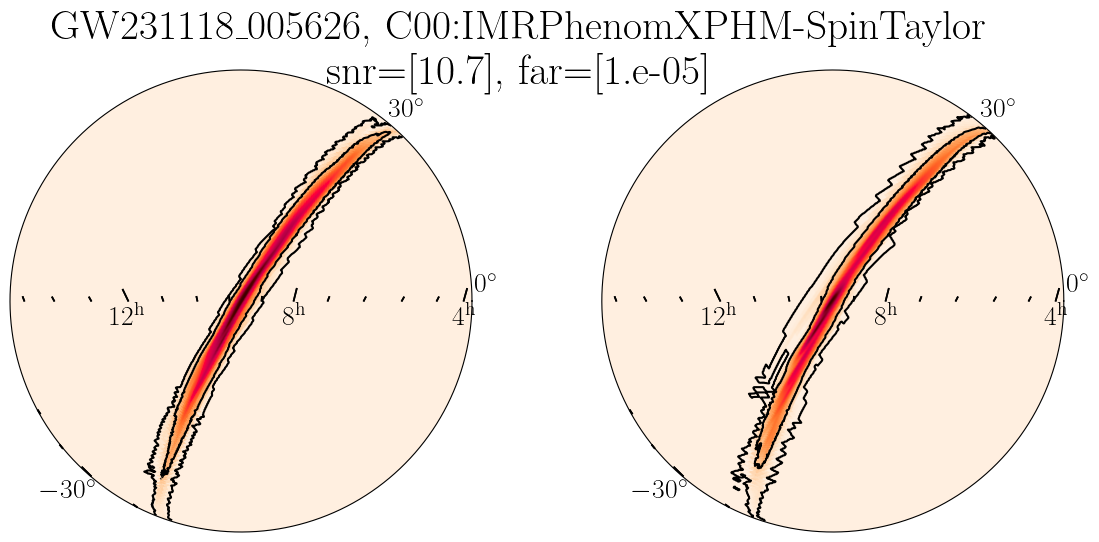

In [30]:
from pathlib import Path

BASE = Path("/home/lucas/Documents/PhD/gw_data")

def get_lvk_skymap(gwname, approximant):

    if approximant == "C00:IMRPhenomXPHM-SpinTaylor":
        apx_name = "IMRPhenomXPHM_SpinTaylor"
    else:
        apx_name = approximant.split(":")[-1]
    paths = [
        BASE / f"gwtc5/IGWN-GWTC5p0-29ebe06b7_25-Archived_Skymaps/parameter_estimation/skymaps/IGWN-GWTC5p0-29ebe06b7_25-{gwname}-{apx_name}_Skymap_PEDataRelease.fits.gz",
        BASE / f"IGWN-GWTC4p0-1a206db3d_721-Archived_Skymaps/IGWN-GWTC4p0-1a206db3d_721-{gwname}-{apx_name}_Skymap_PEDataRelease.fits.gz",
        BASE / f"IGWN-GWTC3p0-v2-PESkyLocalizations/IGWN-GWTC3p0-v2-{gwname}_PEDataRelease_cosmo_reweight_{approximant}.fits",
        BASE / f"IGWN-GWTC2p1-v2-PESkyMaps/IGWN-GWTC2p1-v2-{gwname}_PEDataRelease_cosmo_reweight_{approximant}.fits"
    ]

    errors = []
    for path in paths:
        try:
            return read_sky_map(path)
        except Exception as e:
            errors.append(f"{path}: {e}")
    raise FileNotFoundError(
        f"Could not find skymap for {gwname=} {approximant=}\n"
        + "\n".join(errors)
    )

for key in prior_dict.keys():
    # if key != 'GW231123_135430':
    #     continue

    run = get_run(key)
    if run != 'O4':
        continue

    apx, prior = prior_dict[key]

    try:
        map_path = f'/home/lucas/Documents/PhD/gw_data/reweighted-gwtc5/skymaps/{key}.fits.gz'
        prob, _ = read_sky_map(map_path)
    except:
        continue
        
    cls = find_greedy_credible_levels(prob)

    ipix_max = np.argmax(prob)
    nside = hp.npix2nside(len(prob))
    theta, phi = hp.pix2ang(nside, ipix_max)
    ra = np.degrees(phi)
    dec = 90 - np.degrees(theta)

    center = SkyCoord(ra, dec, unit="deg")

    prob_lvk, _ = get_lvk_skymap(key, apx)
    cls_lvk = find_greedy_credible_levels(prob_lvk)

    fig, axs = plt.subplots(
        1, 2,
        figsize=(14, 6),
        subplot_kw={
            "projection": "astro globe",
            "center": center,
        },
    )

    axs[0].contour_hpx(
        cls,
        levels=[0.9, 0.999],
        colors="black",
        linewidths=1.5,
    )
    
    axs[0].imshow_hpx(prob, cmap='cylon')

    axs[1].contour_hpx(
        cls_lvk,
        levels=[0.9, 0.999],
        colors="black",
        linewidths=1.5,
    )
    
    axs[1].imshow_hpx(prob_lvk, cmap='cylon')

    plt.suptitle(f'{key}, {apx}\nsnr={snr_dict[key]}, far={far_dict[key]}', fontsize=30)
    plt.show()
    break


In [31]:
# from ligo.skymap.kde import Clustered2Plus1DSkyKDE
# from ligo.skymap import moc

# os.environ["OMP_NUM_THREADS"] = "1"

# key = 'GW230702_185453'
# apx, prior = prior_dict[key]
# path = PEpaths[key]
# with h5py.File(path, 'r') as f:
#     data = f[apx]['posterior_samples']

#     samples = np.column_stack((data["ra"], data["dec"], data["luminosity_distance"]))

# for kmax in [31]:
#     kde = Clustered2Plus1DSkyKDE(samples, max_k=kmax, jobs=24)
    
#     # Multi-order skymap
#     m = kde.as_healpix()

#     # Rasterize to fixed resolution
#     raster = moc.rasterize(m, order=9)

#     # Probability density per steradian
#     probdensity = raster["PROBDENSITY"]

#     # Convert to probability per pixel
#     nside = hp.npix2nside(len(probdensity))
#     pixarea_sr = hp.nside2pixarea(nside)

#     prob = probdensity * pixarea_sr
#     prob /= prob.sum()

#     # Credible levels
#     cls = find_greedy_credible_levels(prob)

#     # Areas
#     pixarea_deg2 = hp.nside2pixarea(nside, degrees=True)

#     area50 = np.sum(cls <= 0.5) * pixarea_deg2
#     area90 = np.sum(cls <= 0.9) * pixarea_deg2

#     # MAP position
#     ipix_max = np.argmax(prob)

#     theta, phi = hp.pix2ang(nside, ipix_max)

#     ra = np.degrees(phi)
#     dec = 90 - np.degrees(theta)

#     print(
#         f"kmax={kmax:2d}  "
#         f"k={kde.k:2d}  "
#         f"area50={area50:8.2f} deg²  "
#         f"area90={area90:8.2f} deg²  "
#         f"MAP=({ra:.2f}, {dec:.2f})"
#     )


In [32]:
# Write new skymap paths to .json file
skymap_directory = '/home/lucas/Documents/PhD/gw_data/reweighted-gwtc5/skymaps'
outpath = '/home/lucas/Documents/PhD/gw_data/reweighted-gwtc5/real_skymaps_reweight_gwtc5.json'

skymap_dict = {}
for file in glob.glob(f'{skymap_directory}/*.fits.gz'):
    gwname = file.split('/')[-1].split('.')[0]
    skymap_dict[gwname] = file
print(len(skymap_dict.keys()), skymap_dict.keys())

with open(outpath, 'w') as outfile:
    json.dump(skymap_dict, outfile)


256 dict_keys(['GW230706_104333', 'GW230825_041334', 'GW191222_033537', 'GW190731_140936', 'GW190725_174728', 'GW240530_012417', 'GW231108_125142', 'GW240519_012815', 'GW240622_004008', 'GW250118_055802', 'GW230806_204041', 'GW231231_154016', 'GW230723_101834', 'GW240501_033534', 'GW230824_033047', 'GW240612_081540', 'GW241114_235258', 'GW241109_033317', 'GW231001_140220', 'GW241111_111552', 'GW240830_211120', 'GW240915_001357', 'GW230814_230901', 'GW241130_110422', 'GW231005_021030', 'GW190412_053044', 'GW230924_124453', 'GW241210_060606', 'GW231206_233134', 'GW231114_043211', 'GW240420_175625', 'GW200208_130117', 'GW230814_061920', 'GW190517_055101', 'GW170809_082821', 'GW240505_133552', 'GW190727_060333', 'GW230820_212515', 'GW240615_160735', 'GW250109_010541', 'GW241130_034908', 'GW231113_200417', 'GW230920_071124', 'GW230624_113103', 'GW230726_002940', 'GW240618_071627', 'GW250118_023225', 'GW190828_063405', 'GW231129_081745', 'GW241102_144729', 'GW230712_090405', 'GW200225_060421

# Preparation is done. Run the main code.

# Now plot the posteriors including selection effects

44.5_kulkarni
256
alpha: 0.2504123972451084 0.41078336883249716
MAX LOG-LLH IS -6377.468092076665

45.5_kulkarni
256
alpha: 0.14629632091393052 0.41078336883249716
MAX LOG-LLH IS -6377.3779592758

46.5_kulkarni
256
alpha: 0.03168441448638874 0.41078336883249716
MAX LOG-LLH IS -6376.650306821315

44.5_kulkarni
256
alpha: 0.2504453481898237 0.41078336883249716
MAX LOG-LLH IS -6377.383049859628

45.5_kulkarni
256
alpha: 0.1463228591928513 0.41078336883249716
MAX LOG-LLH IS -6377.319877799107

46.5_kulkarni
256
alpha: 0.03146192870235628 0.41078336883249716
MAX LOG-LLH IS -6376.7845684086915



/tmp/ipykernel_851740/3635121806.py:112: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['', 0.5, 1, 1.5, 2, 2.5, 3])


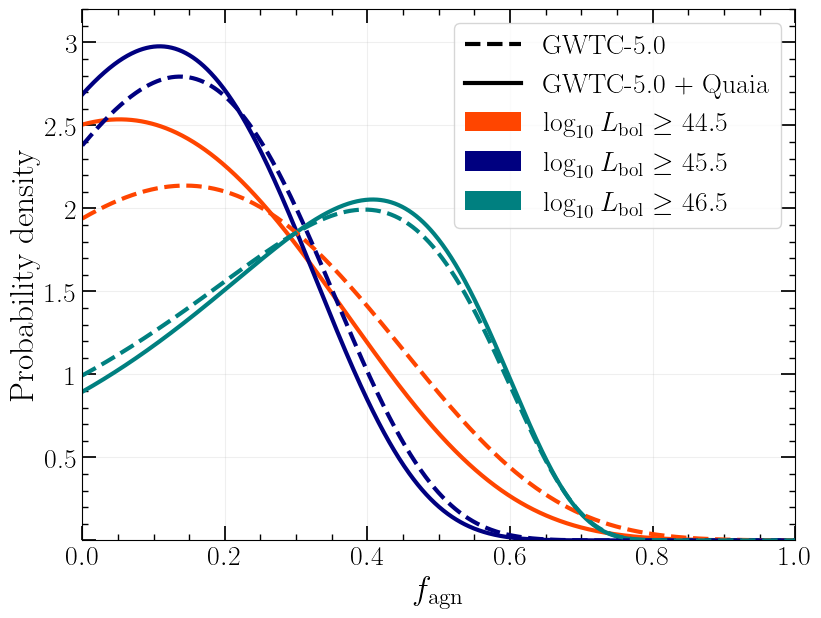

In [ ]:
snr_thr = 10  # Just keeping these here to not have an error, however, I do not calculate alpha on the fly anymore, so changing these is not reflected in alpha!!
far_thr = 1
label = '_zleq3_final_kmax5_gwtc5_luminformed_smoothcorr'  #'_zleq3_final_kmax5_gwtc5_luminformed'  # '_zleq3_final_kmax5_gwtc5_neglecterror'  # _MF
# agn_zcut = 3.0
# rate_parameters = {"b": 3.3, "c": 2.55, "d": 6.1}


for zmodel in ['madau']:  # , 'lowZ_sfr', 'madau_lvk_MAP'

    json_withcat = f'/home/lucas/Documents/PhD/gw_data/real_output_{zmodel}{label}.json'
    json_emptycat = f'/home/lucas/Documents/PhD/gw_data/real_output_nocat_{zmodel}{label}.json'

    fig, ax = plt.subplots(figsize=(4 * 2.3, 3 * 2.3))

    for k, json_path in enumerate([json_withcat, json_emptycat]):

        if k == 0:  # With catalogue
            lab = 'With catalogue'
            linestyle = 'solid'
        else:
            lab = 'Without catalogue'
            linestyle = 'dashed'

        with open(json_path, "r") as f:
            data = json.load(f)

        for i, thresh in enumerate(['44.5_kulkarni', '45.5_kulkarni', '46.5_kulkarni']):  # , '45.0_kulkarni', '46.0_kulkarni', 
            print(thresh)

            gw_evidence_dict = data[str(thresh)]

            log_llh = 0
            nO1 = 0
            nO2 = 0
            nO3 = 0
            nO4 = 0
            for gwkey in gw_evidence_dict.keys():

                run = get_run(gwkey)
                if run in ['O3', 'O4']:
                    if far_dict[gwkey] > far_thr:
                        continue
                
                elif run in ['O1', 'O2']:
                    if snr_dict[gwkey] < snr_thr:
                        continue

                if run == 'O1':
                    nO1 += 1
                elif run == 'O2':
                    nO2 += 1
                elif run == 'O3':
                    nO3 += 1
                elif run == 'O4':
                    nO4 += 1
                
                S_agn_incat = gw_evidence_dict[gwkey]['S_agn_incat']
                S_agn_outofcat = gw_evidence_dict[gwkey]['S_agn_outcat']
                S_alt = gw_evidence_dict[gwkey]['S_alt']

                # print(f'GW: {gwkey}, Sagn incat: {S_agn_incat}, Sagn outcat: {S_agn_outofcat}, Salt: {S_alt}')

                log_llh += np.log(LOG_LLH_X_AX * (S_agn_incat + S_agn_outofcat - S_alt) + S_alt)
            print(nO1 + nO2 + nO3 + nO4)
            # print(nO1, nO2, nO3, nO4, nO1 + nO2 + nO3 + nO4)
            # print('check', alph(thresh.split('_')[0])[0])
            
            alpha_agn = gw_evidence_dict[gwkey]['alpha_agn']  # Same for all events
            alpha_alt = gw_evidence_dict[gwkey]['alpha_alt']  # Same for all events

            # alpha_alt, alpha_agn, _ = alph(thresh.split('_')[0])
            print('alpha:', alpha_agn, alpha_alt)

            log_llh -= (nO1 + nO2 + nO3 + nO4) * np.log(LOG_LLH_X_AX * alpha_agn + (1 - LOG_LLH_X_AX) * alpha_alt)
            # cdf = get_cdfs(log_llh)
            # cdf_interp = CubicSpline(LOG_LLH_X_AX, cdf)
            # from scipy.optimize import brentq
            # x95 = brentq(lambda x: cdf_interp(x) - 0.95, LOG_LLH_X_AX[0], LOG_LLH_X_AX[-1])
            # print(x95, 'AAA')
            
            print(f'MAX LOG-LLH IS {np.max(log_llh)}\n')
            pdfs = get_pdfs(log_llh, LOG_LLH_X_AX)
            if linestyle == 'solid':
                label = r'$\log_{10} L_{\rm bol} \geq$ ' + str(thresh.split('_')[0])
            else:
                label = ''
            ax.plot(LOG_LLH_X_AX, pdfs, color=COLORS[i], linewidth=3, linestyle=linestyle)

    # ax.hlines(1, 0, 1, linestyles='dotted', colors='black', label='Prior', linewidth=3)
    ax.grid(alpha=0.2)

    handles, labels = ax.get_legend_handles_labels()
    custom_handles = [
        Line2D([], [], color='black', linestyle='dashed', linewidth=3, label='GWTC-5.0'),
        Line2D([], [], color='black', linestyle='solid', linewidth=3, label='GWTC-5.0 + Quaia'),
        Patch(facecolor=COLORS[0], edgecolor='none',
            label=r'$\log_{10} L_{\rm bol} \geq 44.5$'),

        Patch(facecolor=COLORS[1], edgecolor='none',
            label=r'$\log_{10} L_{\rm bol} \geq 45.5$'),

        Patch(facecolor=COLORS[2], edgecolor='none',
            label=r'$\log_{10} L_{\rm bol} \geq 46.5$'),
    ]

    handles = custom_handles + handles
    ax.legend(handles=handles)
    ax.set_xlabel(r'$f_{\rm agn}$')
    ax.set_ylabel('Probability density')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 3.2)
    ax.set_yticklabels(['', 0.5, 1, 1.5, 2, 2.5, 3])
    # ax.set_title(zmodel)
    # ax.semilogy()
    # plt.savefig('p26plots_v2/fixed_zpop_posterior.pdf', bbox_inches='tight')
    plt.show()


GW190828_065509 21.785579556784
GW190828_065509 21.785579556784
GW190630_185205 33.30636288927647
GW190929_012149 50.3100212081044
GW190924_021846 8.111088578237208
GW190602_175927 62.045576909463016
GW190521_030229 83.37949931478038
GW231123_135430 145.75365545389485
GW241109_115924 6.491349027364953
Minmass: 6.491349027364953, Maxmass: 145.75365545389485
46.5_kulkarni


TypeError: alpha() got an unexpected keyword argument 'emptycat'

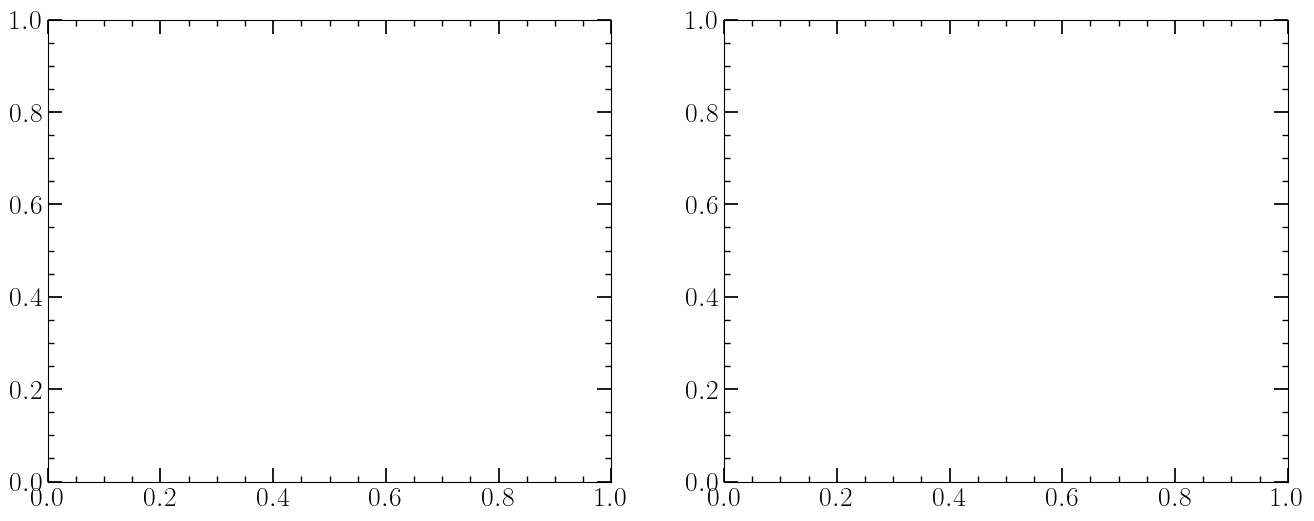

In [34]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

minmass = np.inf
maxmass = -np.inf
for key in reweight_PEdict.keys():
    primary_mass = mass_dict[key][0]
    if primary_mass < minmass:
        minmass = primary_mass
        print(key, primary_mass)
    if primary_mass > maxmass:
        maxmass = primary_mass
        print(key, primary_mass)
print(f'Minmass: {minmass}, Maxmass: {maxmass}')

colnorm = mcolors.Normalize(vmin=minmass, vmax=maxmass)
cmap = cm.viridis

label = '_gwtc5'

for zmodel in ['madau', 'madau_lvk_MAP', 'lowZ_sfr']:
    alpha_withcat = lambda lum: alpha(agn_zpop=lum, fagn=LOG_LLH_X_AX, snr_thr=10, far_thr=1, emptycat=False, redshift_model=zmodel)
    alpha_emptycat = lambda lum: alpha(agn_zpop=lum, fagn=LOG_LLH_X_AX, snr_thr=10, far_thr=1, emptycat=True, redshift_model=zmodel)

    json_withcat = f'/home/lucas/Documents/PhD/gw_data/real_output_{zmodel}{label}.json'
    json_emptycat = f'/home/lucas/Documents/PhD/gw_data/real_output_nocat_{zmodel}{label}.json'


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

    for k, (json_path, alph, ax) in enumerate(zip([json_withcat, json_emptycat], [alpha_withcat, alpha_emptycat], [ax1, ax2])):

        if k == 0:  # With catalogue
            lab = 'With catalogue'
            linestyle = 'solid'
        else:
            lab = 'Without catalogue'
            linestyle = 'dashed'

        with open(json_path, "r") as f:
            data = json.load(f)

        for i, thresh in enumerate(['46.5_kulkarni']):  # '44.5_kulkarni', '45.0_kulkarni', '45.5_kulkarni', '46.0_kulkarni', 
            print(thresh)

            log_detection_efficiency = np.log( alph(thresh.split('_')[0]) )

            gw_evidence_dict = data[str(thresh)]

            log_llh = 0
            nO1 = 0
            nO2 = 0
            nO3 = 0
            nO4 = 0
            for gwkey in gw_evidence_dict.keys():

                run = get_run(gwkey)
                # if run != 'O3':
                #     continue

                # if mass_dict[gwkey][0] > 40:
                #     continue

                if run == 'O1':
                    nO1 += 1
                elif run == 'O2':
                    nO2 += 1
                elif run == 'O3':
                    nO3 += 1
                elif run == 'O4':
                    nO4 += 1
                
                S_agn_incat = gw_evidence_dict[gwkey]['S_agn_incat']
                S_agn_outofcat = gw_evidence_dict[gwkey]['S_agn_outcat']
                S_alt = gw_evidence_dict[gwkey]['S_alt']

                single_event_log_llh = np.log(LOG_LLH_X_AX * (S_agn_incat + S_agn_outofcat - S_alt) + S_alt) - log_detection_efficiency

                single_event_posterior = single_event_log_llh - np.max(single_event_log_llh)
                pdf = np.exp(single_event_posterior)
                norm = simpson(y=pdf, x=LOG_LLH_X_AX, axis=0)  # Simpson should be fine...
                pdf = pdf / norm

                # print(np.sum(np.isnan(pdf)))

                if gwkey == 'GW231123_135430':
                    ax.plot(LOG_LLH_X_AX, pdf, linewidth=3, color=cmap(colnorm(mass_dict[gwkey][0])), alpha=0.5, zorder=10)
                else:
                    ax.plot(LOG_LLH_X_AX, pdf, linewidth=3, color=cmap(colnorm(mass_dict[gwkey][0])), alpha=0.5)

                log_llh += single_event_log_llh
            
            # print(nO1, nO2, nO3, nO4, nO1 + nO2 + nO3 + nO4)
            # print(alph('1'))
            # log_llh -= (nO1 + nO2 + nO3 + nO4) * np.log(alph(thresh.split('_')[0]))

            pdfs = get_pdfs(log_llh, LOG_LLH_X_AX)
            ax.plot(LOG_LLH_X_AX, pdfs, color=COLORS[i], linewidth=3, linestyle=linestyle, label=f'{thresh.split('_')[0]}, {lab}')

        ax.hlines(1, 0, 1, linestyles='dotted', colors='black', label='Prior', linewidth=3)
        ax.grid()
        ax.legend()
        ax.set_xlabel(r'$f_{\rm agn}$')
        ax.set_ylabel('Probability density')
        ax.set_xlim(0, 1)
        ax.set_title(zmodel)
    # ax.semilogy()
    # plt.savefig('p26plots/46p5_preliminary_posterior.pdf', bbox_inches='tight')
    plt.show()


In [ ]:
def contour_levels(H, cred_levels=(0.68, 0.90)):
    """
    Compute density thresholds corresponding to given credible regions.
    """
    Hflat = H.flatten()
    idx = np.argsort(Hflat)[::-1]
    Hsorted = Hflat[idx]

    cumsum = np.cumsum(Hsorted)
    cumsum /= cumsum[-1]

    levels = []
    for cl in cred_levels:
        levels.append(Hsorted[np.searchsorted(cumsum, cl)])

    return np.array(levels)


def plot_credible_contours(x, y, ax, bins=50, cred_levels=(0.68, 0.90), color=np.random.uniform()):
    H, xedges, yedges = np.histogram2d(x, y, bins=bins)

    # bin centers
    xc = 0.5 * (xedges[:-1] + xedges[1:])
    yc = 0.5 * (yedges[:-1] + yedges[1:])

    levels = contour_levels(H, cred_levels)

    # contour levels must be increasing
    levels = np.sort(levels)

    ax.contour(
        xc,
        yc,
        H.T,
        levels=levels,
        colors=[color],
    )

    

In [ ]:
norm = plt.Normalize(vmin=0, vmax=1)

zmodel = 'madau'
label = '_gwtc5'

alpha_withcat = lambda lum: alpha(agn_zpop=lum, fagn=LOG_LLH_X_AX, snr_thr=10, far_thr=1, emptycat=False, redshift_model=zmodel)
alpha_emptycat = lambda lum: alpha(agn_zpop=lum, fagn=LOG_LLH_X_AX, snr_thr=10, far_thr=1, emptycat=True, redshift_model=zmodel)

json_withcat = f'/home/lucas/Documents/PhD/gw_data/real_output_{zmodel}{label}.json'
json_emptycat = f'/home/lucas/Documents/PhD/gw_data/real_output_nocat_{zmodel}{label}.json'

json_path = json_withcat
alph = alpha_withcat

with open(json_path, "r") as f:
    data = json.load(f)

for i, thresh in enumerate(['46.5_kulkarni', '45.5_kulkarni', '44.5_kulkarni']):  # '44.5_kulkarni', '45.0_kulkarni', '45.5_kulkarni', '46.0_kulkarni', 
    print(thresh)
    log_detection_efficiency = np.log( alph(thresh.split('_')[0]) )
    gw_evidence_dict = data[str(thresh)]



    fig, ax = plt.subplots(figsize=(8,6))

    for key in gw_evidence_dict.keys():

        # if key.split('_')[0] != 'GW190521':
        #     continue

        approximant, prior = prior_dict[key]
        prior = prior_from_bytes(prior[0])

        path = reweight_PEdict[key]
        
        with h5py.File(path, 'r') as f:
            posterior_samples = f[approximant]['posterior_samples']

            x = posterior_samples['mass_1_source']
            y = posterior_samples['chi_eff']

            x16, x50, x84 = np.quantile(x, [0.16, 0.50, 0.84])
            y16, y50, y84 = np.quantile(y, [0.16, 0.50, 0.84])

        
        S_agn_incat = gw_evidence_dict[key]['S_agn_incat']
        S_agn_outofcat = gw_evidence_dict[key]['S_agn_outcat']
        S_alt = gw_evidence_dict[key]['S_alt']
        single_event_log_llh = np.log(LOG_LLH_X_AX * (S_agn_incat + S_agn_outofcat - S_alt) + S_alt) - log_detection_efficiency
        single_event_posterior = single_event_log_llh - np.max(single_event_log_llh)
        pdf = np.exp(single_event_posterior)
        n = simpson(y=pdf, x=LOG_LLH_X_AX, axis=0)  # Simpson should be fine...
        pdf = pdf / n

        cdf = np.cumsum(pdf)
        cdf /= np.max(cdf)
        inverse_cdf = interp1d(cdf, LOG_LLH_X_AX, bounds_error=False, fill_value='extrapolate')
        q016 = inverse_cdf(0.16)
        q050 = inverse_cdf(0.50)
        q084 = inverse_cdf(0.84)

        # plot_credible_contours(x, y, ax, bins=50, cred_levels=np.array([0.68]), color=plt.cm.viridis(norm(q050)))
        # print(np.median(x),    q050)
        # ax.errorbar(
        #     x50,
        #     q050,
        #     xerr=[[x50 - x16], [x84 - x50]],
        #     yerr=[[q050 - q016], [q084 - q050]],
        #     fmt='o',
        #     color=plt.cm.viridis(norm(y50)),
        #     capsize=3,
        #     alpha=0.5
        # )       

        ax.errorbar(
            x50,
            y50,
            xerr=[[x50 - x16], [x84 - x50]],
            yerr=[[y50 - y16], [y84 - y50]],
            fmt='o',
            color=plt.cm.viridis(norm(q050)),
            capsize=3,
            alpha=0.5
        )
    sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=0, vmax=1), cmap="viridis")
    fig.colorbar(sm, ax=ax, label=r"Median $f_{\rm agn}$")
    ax.semilogx()
    ax.set_ylim(-1, 1)
    ax.set_xlabel('Primary mass')
    ax.set_ylabel(r'$\chi_{\rm eff}$')
    plt.show()


46.5_kulkarni


TypeError: alpha() got an unexpected keyword argument 'emptycat'

In [ ]:
norm = plt.Normalize(vmin=0, vmax=1)

zmodel = 'madau'
label = '_gwtc5'
alpha_withcat = lambda lum: alpha(agn_zpop=lum, fagn=LOG_LLH_X_AX, snr_thr=10, far_thr=1, emptycat=False, redshift_model=zmodel)
alpha_emptycat = lambda lum: alpha(agn_zpop=lum, fagn=LOG_LLH_X_AX, snr_thr=10, far_thr=1, emptycat=True, redshift_model=zmodel)

json_withcat = f'/home/lucas/Documents/PhD/gw_data/real_output_{zmodel}{label}.json'
json_emptycat = f'/home/lucas/Documents/PhD/gw_data/real_output_nocat_{zmodel}{label}.json'

json_path = json_withcat
alph = alpha_withcat

with open(json_path, "r") as f:
    data = json.load(f)

for i, thresh in enumerate(['46.5_kulkarni', '45.5_kulkarni', '44.5_kulkarni']):  # '44.5_kulkarni', '45.0_kulkarni', '45.5_kulkarni', '46.0_kulkarni', 
    print(thresh)
    log_detection_efficiency = np.log( alph(thresh.split('_')[0]) )
    gw_evidence_dict = data[str(thresh)]



    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

    for key in gw_evidence_dict.keys():
        
        S_agn_incat = gw_evidence_dict[key]['S_agn_incat']
        S_agn_outofcat = gw_evidence_dict[key]['S_agn_outcat']
        S_alt = gw_evidence_dict[key]['S_alt']
        single_event_log_llh = np.log(LOG_LLH_X_AX * (S_agn_incat + S_agn_outofcat - S_alt) + S_alt) - log_detection_efficiency
        single_event_posterior = single_event_log_llh - np.max(single_event_log_llh)
        pdf = np.exp(single_event_posterior)
        n = simpson(y=pdf, x=LOG_LLH_X_AX, axis=0)  # Simpson should be fine...
        pdf = pdf / n

        cdf = np.cumsum(pdf)
        cdf /= np.max(cdf)
        inverse_cdf = interp1d(cdf, LOG_LLH_X_AX, bounds_error=False, fill_value='extrapolate')
        q016 = inverse_cdf(0.16)
        q050 = inverse_cdf(0.50)
        q084 = inverse_cdf(0.84)

        if get_run(key) in ['O1', 'O2']:
            ax1.errorbar(
                snr_dict[key],
                q050,
                yerr=[[q050 - q016], [q084 - q050]],
                fmt='o',
                capsize=3,
                alpha=0.5,
                color='grey'
            )
        else:
            ax2.errorbar(
                far_dict[key],
                q050,
                yerr=[[q050 - q016], [q084 - q050]],
                fmt='o',
                capsize=3,
                alpha=0.5,
                color='grey'
            )
        
    # ax.semilogx()
    # ax.set_ylim(-1, 1)
    ax1.set_xlabel('SNR')
    ax1.set_ylabel(r'$f_{\rm agn}$')
    ax2.set_xlabel('FAR')
    ax2.set_ylabel(r'$f_{\rm agn}$')
    ax2.semilogx()
    plt.show()


46.5_kulkarni


TypeError: alpha() got an unexpected keyword argument 'emptycat'

In [ ]:


# b                  = b[outside_galactic_plane & above_lbol_thresh]
# loglbol_corr       = loglbol_corr[outside_galactic_plane & above_lbol_thresh]
# agn_redshift_err   = data["redshift_quaia_err"].to_numpy()[outside_galactic_plane & above_lbol_thresh]
# agn_ra             = np.deg2rad( data["ra"].to_numpy()[outside_galactic_plane & above_lbol_thresh] )
# agn_dec            = np.deg2rad( data["dec"].to_numpy()[outside_galactic_plane & above_lbol_thresh] )

# agn_posterior_dset, _ = get_agn_posteriors(fagn_idx, agn_redshift, agn_redshift_err, label=cfg.LUM_THRESH, cfg=cfg, replace_old_file=True)
# # _, c_per_zbin, completeness_map = make_incomplete_catalog(agn_ra, agn_dec, agn_rlum, agn_redshift)  # Quaia is already redshift incomplete, but convenient to get completeness maps this way

# filename = f'{cfg.AGN_DIST_DIR}/completeness_{cfg.LUM_THRESH}_{cfg.QLF}.npy'
# if cfg.VERBOSE:
#     print(f'Loading continuous selection function calculated from QLF from file: {filename}')
# z, fc_of_z = np.load(filename)
# c_above_1 = fc_of_z > 1
# fc_of_z[c_above_1] = 1.
# redshift_completeness = interp1d(z, fc_of_z, bounds_error=False, fill_value=0)

# return agn_posterior_dset, agn_ra, agn_dec, agn_redshift, redshift_completeness

GW190805_211137 7.94 %
GW230819_171910 6.68 %
GW231230_170116 21.17 %
GW230928_215827 5.99 %
GW231119_075248 27.32 %
GW230704_212616 53.54 %
GW230806_204041 5.28 %
GW230922_040658 12.64 %
GW230630_125806 20.11 %
GW240107_013215 19.54 %
GW231001_140220 7.9 %
GW231005_021030 25.22 %
GW241229_155844 24.02 %
GW240527_183429 7.59 %
GW240601_061200 8.11 %
GW240621_214041 20.0 %
GW240618_071627 30.76 %
GW240824_205609 33.18 %
GW241116_151753 18.73 %
GW240612_081540 17.21 %
GW241201_055758 27.18 %
GW250118_023225 5.02 %
GW241125_010116 5.99 %


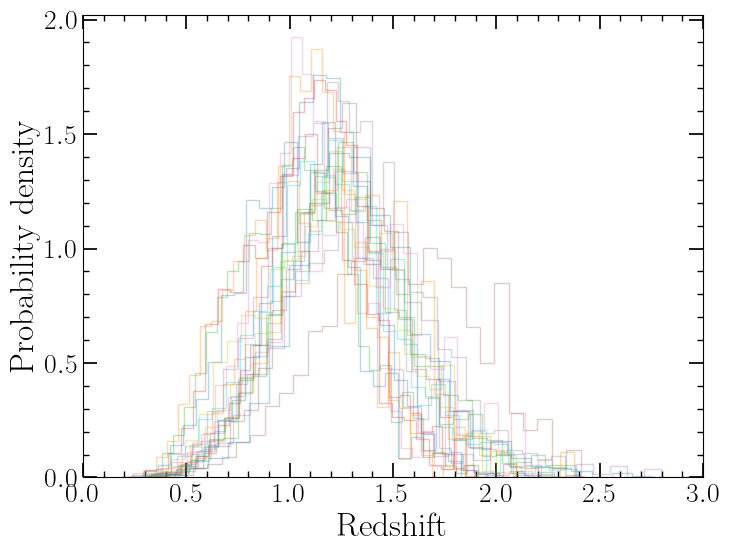

23 256


In [ ]:
lum = 46.5

df = pd.read_csv("/home/lucas/Documents/PhD/agn_data/Quaia_z15.csv")
cols = ["redshift_quaia", "redshift_quaia_err", "ra", "dec", "b", "loglbol_corr"]
data = df[cols]
b              = data["b"].to_numpy()
loglbol_corr   = data["loglbol_corr"].to_numpy()

outside_galactic_plane = np.logical_or((b > 10), (b < -10))

def get_agn_z(lum):
    above_lbol_thresh = loglbol_corr >= float(lum)
    return data["redshift_quaia"].to_numpy()[outside_galactic_plane & above_lbol_thresh]


agn_z = [get_agn_z(44.5), get_agn_z(45.5), get_agn_z(46.5)]

fig, ax = plt.subplots(figsize=(8,6))

n = 0
B = []
for key in reweight_PEdict.keys():

    # if not ((key[:4] == 'GW24') or (key[:4] == 'GW25')):
    #     continue

    approximant, prior = prior_dict[key]
    prior = prior_from_bytes(prior[0])

    path = reweight_PEdict[key]
    
    with h5py.File(path, 'r') as f:
        posterior_samples = f[approximant]['posterior_samples']

        x = posterior_samples['redshift']

        if np.sum(x > 1.5) / len(x) > 0.05:
            print(key, 100 * np.sum(x > 1.5) / len(x), '%')
            B.append(key)
            n += 1
        else:
            continue

        x16, x50, x84 = np.quantile(x, [0.16, 0.50, 0.84])

    ax.hist(x, density=True, histtype='step', bins=30, alpha=0.3)
# ax.hist(agn_z, stacked=True, density=True, histtype='step', bins=30, linewidth=3, color=COLORS[:3])
# ax.semilogy()
plt.xlabel('Redshift')
plt.ylabel('Probability density')
# plt.legend()
# plt.ylim(0, 5)
plt.xlim(0, 3)
plt.show()

print(n, len(reweight_PEdict.keys()))
